- Quick Machine Learning Revision
   - Supervised ML
   - Unsupervised ML

- Supervised ML 
***
   - Linear Regression
   - Ridge & Lasso Regression
   - Logistic Regression

In [1]:
## Linear Regression
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("D:\AIML Prime\Machine_Learning\Supervised_ML\insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [4]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
df.nunique()

age           47
sex            2
bmi          548
children       6
smoker         2
region         4
charges     1337
dtype: int64

<Axes: xlabel='bmi', ylabel='charges'>

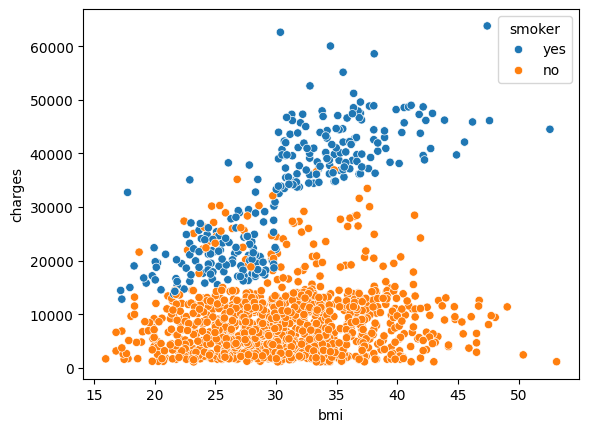

In [7]:
## Visualize Data
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(
    x='bmi',
    y='charges',
    hue='smoker',
    data=df
)


In [8]:
X = df.drop(columns=['charges','region'])
y = df['charges']

In [9]:
X.head()

,age,sex,bmi,children,smoker
0,19,female,27.900,0,yes
1,18,male,33.770,1,no
2,28,male,33.000,3,no
3,33,male,22.705,0,no
4,32,male,28.880,0,no


In [10]:
y.head()

0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64

In [11]:
## Converting Into Numerical Data
X['sex'] = X['sex'].map({'female':1,'male':0})
X['smoker'] = X['smoker'].map({'yes':1,'no':0})


In [12]:
X.head()

,age,sex,bmi,children,smoker
0,19,1,27.900,0,1
1,18,0,33.770,1,0
2,28,0,33.000,3,0
3,33,0,22.705,0,0
4,32,0,28.880,0,0


In [13]:
## Train Test Split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(
     X,y,test_size=0.3,random_state=42
)

In [14]:
X_train.head()

,age,sex,bmi,children,smoker
332,61,1,31.160,0,0
355,46,0,27.600,0,0
138,54,1,31.900,3,0
381,55,0,30.685,0,1
292,25,0,45.540,2,1


In [15]:
X_test.head()

,age,sex,bmi,children,smoker
764,45,1,25.175,2,0
887,36,1,30.020,0,0
890,64,1,26.885,0,1
1293,46,0,25.745,3,0
259,19,0,31.920,0,1


In [16]:
## Train  Model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [17]:
## Predicted values
y_pred = model.predict(X_test)
y_pred

array([ 8504.25952786,  6897.83941087, 36805.01178274,  9525.01640181,
       26834.15783554, 11236.53827843,   -56.51533813, 16996.53931939,
         558.86901551, 11292.49638115, 28504.83781808,  9398.41804442,
        5353.29915879, 38679.23753917, 40572.74207294, 37372.20787154,
       15387.38620563, 36033.31348368,  9292.40371143, 31304.88883148,
        4274.20100087, 10592.29487706,  2708.68730205,  6493.02810907,
       11227.74003336, 12498.97075764, 14877.16806499,  5963.85891638,
        9503.12017865,  2360.10282672,  9434.17913244, 12999.67895742,
        4585.98098388,  3265.96837276,  4840.89651399, 12653.62349137,
        2194.59265213,  9123.3897013 , 33175.85413453, 32812.24167496,
        4132.88277765,  4243.29138982, 14495.05758702, 11538.30865769,
        9023.27584285, 12650.54437942,  5036.97193595,  3406.53561573,
       35766.6625433 ,  9379.5276352 , 16062.93310871,  2535.59415356,
       12177.97650916,  1021.65843332, 13742.82492927, 12262.32230678,
      

In [18]:
y_test

764      9095.06825
887      5272.17580
890     29330.98315
1293     9301.89355
259     33750.29180
           ...     
701      9541.69555
672      4399.73100
1163     2200.83085
1103    11363.28320
1295     1964.78000
Name: charges, Length: 402, dtype: float64

In [19]:
## Evaluation
from sklearn.metrics import r2_score

r2 = r2_score(y_test,y_pred)
print(f"r_squared:{r2}")

n = X_test.shape[0]
p = X_test.shape[1]

adjuated_r2 = 1-((1-r2) * (n-1)/(n-p-1))
print(f"adjusted_r2:{adjuated_r2}")

r_squared:0.7680881643600721
adjusted_r2:0.7651599846171437


- Feature Engineering To Enchance Model Performance

In [20]:
X = df.drop('charges',axis=1)
y = df['charges']

In [21]:

X = pd.get_dummies(X,columns=["region"],drop_first=False,dtype=int)

In [22]:
X.head()

,age,sex,bmi,children,smoker,region_northeast,region_northwest,region_southeast,region_southwest
0,19,female,27.900,0,yes,0,0,0,1
1,18,male,33.770,1,no,0,0,1,0
2,28,male,33.000,3,no,0,0,1,0
3,33,male,22.705,0,no,0,1,0,0
4,32,male,28.880,0,no,0,1,0,0


In [23]:
## convert into numerical values.
X['sex'] = X['sex'].map({'female':1,'male':0})
X['smoker'] = X['smoker'].map({'yes':1,'no':0})

X["age_smoker"] = X["age"] * X["smoker"]
X["bmi_smoker"] = X["bmi"] * X["smoker"]

In [24]:
X.head()

,age,sex,bmi,children,smoker,region_northeast,region_northwest,region_southeast,region_southwest,age_smoker,bmi_smoker
0,19,1,27.900,0,1,0,0,0,1,19,27.9
1,18,0,33.770,1,0,0,0,1,0,0,0.0
2,28,0,33.000,3,0,0,0,1,0,0,0.0
3,33,0,22.705,0,0,0,1,0,0,0,0.0
4,32,0,28.880,0,0,0,1,0,0,0,0.0


In [25]:
## Train Test Split
from sklearn.model_selection import train_test_split
X_train,X_test,y_test,y_test = train_test_split(
     X,y,test_size=0.3,random_state=42
)

In [26]:
X_train.head()

,age,sex,bmi,children,smoker,region_northeast,region_northwest,region_southeast,region_southwest,age_smoker,bmi_smoker
332,61,1,31.160,0,0,0,1,0,0,0,0.000
355,46,0,27.600,0,0,0,0,0,1,0,0.000
138,54,1,31.900,3,0,0,0,1,0,0,0.000
381,55,0,30.685,0,1,1,0,0,0,55,30.685
292,25,0,45.540,2,1,0,0,1,0,25,45.540


In [27]:
X_test.head()

,age,sex,bmi,children,smoker,region_northeast,region_northwest,region_southeast,region_southwest,age_smoker,bmi_smoker
764,45,1,25.175,2,0,1,0,0,0,0,0.000
887,36,1,30.020,0,0,0,1,0,0,0,0.000
890,64,1,26.885,0,1,0,1,0,0,64,26.885
1293,46,0,25.745,3,0,0,1,0,0,0,0.000
259,19,0,31.920,0,1,0,1,0,0,19,31.920


In [28]:
## Train Model
from sklearn.linear_model import  LinearRegression
model = LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [29]:
y_pred = model.predict(X_test)
y_pred

array([11204.96088034,  7317.63439439, 33017.38159394, 10904.82707449,
       28167.47391401,  6694.83207739,  2541.40192366, 14632.24854906,
        5451.01024644, 11794.04128381, 20790.1051193 ,  9218.32874966,
        5530.00964359, 51987.64644985, 52118.12779037, 46675.42252427,
       11754.38666322, 43165.11782068, 10047.55046998, 27441.76530528,
        5670.16516614,  9298.6288641 ,  1828.97218927,  4484.97941294,
       12470.16829088, 12867.71485731, 13388.9665309 ,  6363.82045017,
       11782.37374347,  1686.59998508,  9790.2121746 , 13004.1582012 ,
        3050.96684497,  6869.93078155,  4179.25692791, 10232.43569032,
        3158.75298489,  9162.08322774, 26198.96040884, 37684.13494036,
        4618.7169192 ,  3658.3974073 , 12819.0976115 , 12934.67233036,
        6838.82731941, 12962.5983128 ,  4362.80373036,  5138.85613751,
       41659.85048916,  6377.67554355, 14361.66533923,  2148.00257374,
        9200.41949484,  2596.30939177, 12005.781685  , 12320.84753579,
      

In [32]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test,y_pred)
print(f"r_squarred score:{r2}")

n = X_test.shape[0]
p = X_test.shape[1]

adjuated_r2 = 1-((1-r2) * (n-1)/(n-p-1))
print(f"adjusted_r2:{adjuated_r2}")

r_squarred score:0.8623372528708144
adjusted_r2:0.8584544574389656


In [33]:
## Training Data Prediction
y_train_pred = model.predict(X_train)
r2_train = r2_score(y_train,y_train_pred)

print("training data r2:",r2_train)
print("test data r2",r2)

training data r2: 0.8313573701326137
test data r2 0.8623372528708144


In [34]:
## Lasso Regression (L1 Regularization)

import pandas as pd
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.model_selection import train_test_split

In [35]:
## Train Test Split
X_train,X_test,y_train,y_test = train_test_split(
     X,y,test_size=0.3,random_state=42
)

In [36]:
X_train.head()

,age,sex,bmi,children,smoker,region_northeast,region_northwest,region_southeast,region_southwest,age_smoker,bmi_smoker
332,61,1,31.160,0,0,0,1,0,0,0,0.000
355,46,0,27.600,0,0,0,0,0,1,0,0.000
138,54,1,31.900,3,0,0,0,1,0,0,0.000
381,55,0,30.685,0,1,1,0,0,0,55,30.685
292,25,0,45.540,2,1,0,0,1,0,25,45.540


In [37]:
X_test.head()

,age,sex,bmi,children,smoker,region_northeast,region_northwest,region_southeast,region_southwest,age_smoker,bmi_smoker
764,45,1,25.175,2,0,1,0,0,0,0,0.000
887,36,1,30.020,0,0,0,1,0,0,0,0.000
890,64,1,26.885,0,1,0,1,0,0,64,26.885
1293,46,0,25.745,3,0,0,1,0,0,0,0.000
259,19,0,31.920,0,1,0,1,0,0,19,31.920


In [ ]:
## Findout Learning Rate Alpha Value (manual method not suitable for industry grade)
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error

alphas = [0.001, 0.1, 1, 3, 5, 7, 9]
mses = []

for i in alphas:
    lasso = Lasso(alpha=i)
    lasso.fit(X_train, y_train)
    y_pred = lasso.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)   # ✅ fixed
    print(f"MSE for Alpha {i}: {mse}")
    mses.append(mse)


MSE for Alpha 0.001: 20184703.626304433
MSE for Alpha 0.1: 20184568.05964184
MSE for Alpha 1: 20183559.579146173
MSE for Alpha 3: 20182762.982302744
MSE for Alpha 5: 20183958.680791877
MSE for Alpha 7: 20187146.099194158
MSE for Alpha 9: 20192325.010872323


<Axes: >

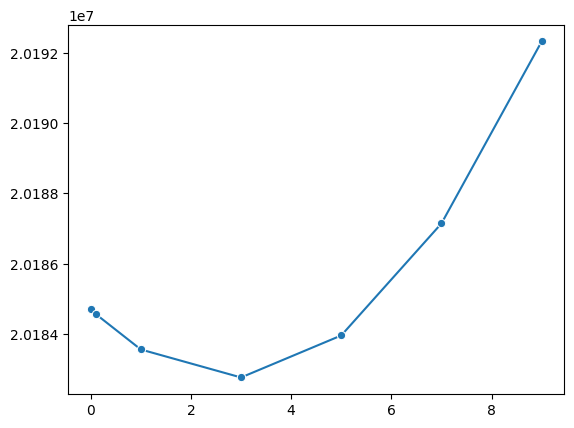

In [45]:
sns.lineplot(x=alphas,y=mses,marker='o')

- LassoCV (L1 Regularization)

In [50]:
## Used LassoCV ti get alpha best value

from sklearn.linear_model import LassoCV
a = [0.001,0.1,1,3,5,7,9,11,20,40,70,100]

cv_model = LassoCV(
    alphas=a,
    cv=7,
    max_iter=3000,
    random_state=42
)

cv_model.fit(X_train, y_train)


,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"n_alphas n_alphas: int, default=100Number of alphas along the regularization path... deprecated:: 1.7 `n_alphas` was deprecated in 1.7 and will be removed in 1.9. Use `alphas` instead.",'deprecated'
,"alphas alphas: array-like or int, default=NoneValues of alphas to test along the regularization path.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`... deprecated:: 1.7 `alphas=None` was deprecated in 1.7 and will be removed in 1.9, at which point the default value will be set to 100.","[0.001, 0.1, ...]"
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: 'auto', bool or array-like of shape (n_features, n_features), default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as argument.",'auto'
,"max_iter max_iter: int, default=1000The maximum number of iterations.",3000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``.",0.0001
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"cv cv: int, cross-validation generator or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- int, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For int/None inputs, :class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",7
,"verbose verbose: bool or int, default=FalseAmount of verbosity.",False
,"n_jobs n_jobs: int, default=NoneNumber of CPUs to use during the cross validation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [51]:
print(f"Best Alpha: {cv_model.alpha_}")

Best Alpha: 0.1


In [53]:
y_pred = cv_model.predict(X_test)

mse = mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)

print(f"MSE:{mse}")
print(f"r_squared:{r2*100}%")

MSE:20184568.05964184
r_squared:86.23381869654474%


- RidgeCV (L2 Regularization)

In [54]:
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_squared_error

a = [0.001,0.1,1,3,5,7,9,11,20,40,70,100]

ridge_cv = RidgeCV(
    alphas=a,
    cv=7
)

ridge_cv.fit(X_train, y_train)


,"alphas alphas: array-like of shape (n_alphas,), default=(0.1, 1.0, 10.0)Array of alpha values to try.Regularization strength; must be a positive float. Regularizationimproves the conditioning of the problem and reduces the variance ofthe estimates. Larger values specify stronger regularization.Alpha corresponds to ``1 / (2C)`` in other linear models such as:class:`~sklearn.linear_model.LogisticRegression` or:class:`~sklearn.svm.LinearSVC`.If using Leave-One-Out cross-validation, alphas must be strictly positive.","[0.001, 0.1, ...]"
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"scoring scoring: str, callable, default=NoneThe scoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: negative :ref:`mean squared error ` if cv is None (i.e. when using leave-one-out cross-validation), or :ref:`coefficient of determination ` (:math:`R^2`) otherwise.",None
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the efficient Leave-One-Out cross-validation- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used, else,:class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.",7
,"gcv_mode gcv_mode: {'auto', 'svd', 'eigen'}, default='auto'Flag indicating which strategy to use when performingLeave-One-Out Cross-Validation. Options are:: 'auto' : use 'svd' if n_samples > n_features, otherwise use 'eigen' 'svd' : force use of singular value decomposition of X when X is dense, eigenvalue decomposition of X^T.X when X is sparse. 'eigen' : force computation via eigendecomposition of X.X^TThe 'auto' mode is the default and is intended to pick the cheaperoption of the two depending on the shape of the training data.",None
,"store_cv_results store_cv_results: bool, default=FalseFlag indicating if the cross-validation values corresponding toeach alpha should be stored in the ``cv_results_`` attribute (seebelow). This flag is only compatible with ``cv=None`` (i.e. usingLeave-One-Out Cross-Validation)... versionchanged:: 1.5 Parameter name changed from `store_cv_values` to `store_cv_results`.",False
,"alpha_per_target alpha_per_target: bool, default=FalseFlag indicating whether to optimize the alpha value (picked from the`alphas` parameter list) for each target separately (for multi-outputsettings: multiple prediction targets). When set to `True`, afterfitting, the `alpha_` attribute will contain a value for each target.When set to `False`, a single alpha is used for all targets... versionadded:: 0.24",False


In [55]:
print(f"Best Alpha: {ridge_cv.alpha_}")

Best Alpha: 0.001


In [57]:
y_pred = ridge_cv.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test,y_pred)

print("Test MSE:", mse)
print(f"r_squared:{r2*100}%")

Test MSE: 20184612.166677393
r_squared:86.2337886148781%


***
- Logistic Regression
- Logistic RegressionCV

In [58]:
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score

df = pd.read_csv("D:\AIML Prime\Machine_Learning\Supervised_ML\heart.csv")

In [59]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [61]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [62]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [63]:
X = df.drop("target",axis=1)
y = df["target"]

In [64]:
X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2


In [65]:
y.head()

0    1
1    1
2    1
3    1
4    1
Name: target, dtype: int64

In [66]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(
     X,y,test_size=0.3,random_state=42
)

In [67]:
X_train.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
124,39,0,2,94,199,0,1,179,0,0.0,2,0,2
72,29,1,1,130,204,0,0,202,0,0.0,2,0,2
15,50,0,2,120,219,0,1,158,0,1.6,1,0,2
10,54,1,0,140,239,0,1,160,0,1.2,2,0,2
163,38,1,2,138,175,0,1,173,0,0.0,2,4,2


In [69]:
X_test.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
179,57,1,0,150,276,0,0,112,1,0.6,1,1,1
228,59,1,3,170,288,0,0,159,0,0.2,1,0,3
111,57,1,2,150,126,1,1,173,0,0.2,2,1,3
246,56,0,0,134,409,0,0,150,1,1.9,1,2,3
60,71,0,2,110,265,1,0,130,0,0.0,2,1,2


In [70]:
y_train[y_train == 1] 
y_train[y_train == 0]

229    0
291    0
273    0
178    0
230    0
      ..
257    0
214    0
302    0
188    0
270    0
Name: target, Length: 97, dtype: int64

In [71]:
model = LogisticRegression(max_iter=10000)
model.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [75]:
y_pred = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test,y_pred)*100}%")
print(f"Precision: {precision_score(y_test,y_pred)*100}%")

Accuracy: 81.31868131868131%
Precision: 82.35294117647058%


In [84]:
## Evaluation Metrics
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score,precision_recall_curve,recall_score,f1_score

print("accuracy score: ", accuracy_score(y_test, y_pred))
print("precision score: ", precision_score(y_test, y_pred))
print("recall score: ", recall_score(y_test, y_pred))
print("F1 score: ", f1_score(y_test, y_pred))

accuracy score:  0.8131868131868132
precision score:  0.8235294117647058
recall score:  0.84
F1 score:  0.8316831683168316


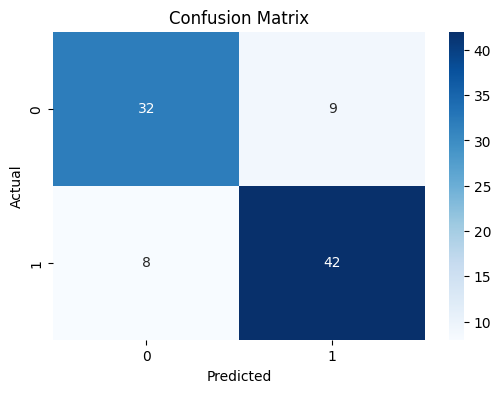

In [85]:
cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [86]:
print(f"classification_report: {classification_report(y_test,y_pred)}")

classification_report:               precision    recall  f1-score   support

           0       0.80      0.78      0.79        41
           1       0.82      0.84      0.83        50

    accuracy                           0.81        91
   macro avg       0.81      0.81      0.81        91
weighted avg       0.81      0.81      0.81        91



In [88]:
## After Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(X_train)
x_test_scaled = scaler.transform(X_test)

model.fit(x_train_scaled,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [91]:
y_pred = model.predict(x_test_scaled)

In [92]:
print("accuracy: ", accuracy_score(y_test, y_pred)*100, "%")
print("precision: ", precision_score(y_test, y_pred)*100, "%")

accuracy:  81.31868131868131 %
precision:  82.35294117647058 %


In [93]:
## Logistic Regression CV

from sklearn.linear_model import LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score

## Sacling
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(X_train)
x_test_scaled = scaler.transform(X_test)

## Model Training
log_cv = LogisticRegressionCV(
    Cs=10,          # number of C values to try
    cv=5,           # 5-fold cross validation
    penalty='l2',   # ridge type regularization
    solver='lbfgs',
    max_iter=3000,
    random_state=42
)

log_cv.fit(x_train_scaled, y_train)

,"Cs Cs: int or list of floats, default=10Each of the values in Cs describes the inverse of regularizationstrength. If Cs is as an int, then a grid of Cs values are chosenin a logarithmic scale between 1e-4 and 1e4.Like in support vector machines, smaller values specify strongerregularization.",10
,"l1_ratios l1_ratios: array-like of shape (n_l1_ratios), default=NoneFloats between 0 and 1 passed as Elastic-Net mixing parameter (scaling betweenL1 and L2 penalties). For `l1_ratio = 0` the penalty is an L2 penalty. For`l1_ratio = 1` it is an L1 penalty. For `0 < l1_ratio < 1`, the penalty is acombination of L1 and L2.All the values of the given array-like are tested by cross-validation and theone giving the best prediction score is used... warning:: Certain values of `l1_ratios`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `l1_ratios=None` is deprecated in 1.8 and will raise an error in version 1.10. Default value will change from `None` to `(0.0,)` in version 1.10.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"cv cv: int or cross-validation generator, default=NoneThe default cross-validation generator used is Stratified K-Folds.If an integer is provided, it specifies the number of folds, `n_folds`, used.See the module :mod:`sklearn.model_selection` module for thelist of possible cross-validation objects... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer dual=False whenn_samples > n_features.",False
,"penalty penalty: {'l1', 'l2', 'elasticnet'}, default='l2'Specify the norm of the penalty:- `'l2'`: add a L2 penalty term (used by default);- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"scoring scoring: str or callable, default=NoneThe scoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: :ref:`accuracy ` is used.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' might be slower in :class:`LogisticRegressionCV` because it does not handle warm-starting.- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one

In [94]:
print("Best C:", log_cv.C_)

Best C: [0.04641589]


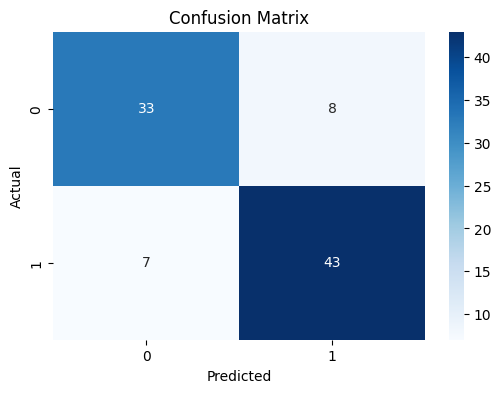

In [95]:
y_pred = log_cv.predict(x_test_scaled)


cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [96]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))

Accuracy: 0.8351648351648352
Precision: 0.8431372549019608


In [97]:
## best Way To Make Pipeline
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
     ('scaler',StandardScaler()),
     ('logistic',LogisticRegressionCV(cv=7,max_iter=3000))
])
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('logistic', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"Cs Cs: int or list of floats, default=10Each of the values in Cs describes the inverse of regularizationstrength. If Cs is as an int, then a grid of Cs values are chosenin a logarithmic scale between 1e-4 and 1e4.Like in support vector machines, smaller values specify strongerregularization.",10
,"l1_ratios l1_ratios: array-like of shape (n_l1_ratios), default=NoneFloats between 0 and 1 passed as Elastic-Net mixing parameter (scaling betweenL1 and L2 penalties). For `l1_ratio = 0` the penalty is an L2 penalty. For`l1_ratio = 1` it is an L1 penalty. For `0 < l1_ratio < 1`, the penalty is acombination of L1 and L2.All the values of the given array-like are tested by cross-validation and theone giving the best prediction score is used... warning:: Certain values of `l1_ratios`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `l1_ratios=None` is deprecated in 1.8 and will raise an error in version 1.10. Default value will change from `None` to `(0.0,)` in version 1.10.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"cv cv: int or cross-validation generator, default=NoneThe default cross-validation generator used is Stratified K-Folds.If an integer is provided, it specifies the number of folds, `n_folds`, used.See the module :mod:`sklearn.model_selection` module for thel

In [98]:
y_pred = pipeline.predict(X_test)

In [99]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))

Accuracy: 0.8131868131868132
Precision: 0.8235294117647058


In [100]:
print(f"classification_report: {classification_report(y_test,y_pred)*100} %")

classification_report:               precision    recall  f1-score   support

           0       0.80      0.78      0.79        41
           1       0.82      0.84      0.83        50

    accuracy                           0.81        91
   macro avg       0.81      0.81      0.81        91
weighted avg       0.81      0.81      0.81        91
              precision    recall  f1-score   support

           0       0.80      0.78      0.79        41
           1       0.82      0.84      0.83        50

    accuracy                           0.81        91
   macro avg       0.81      0.81      0.81        91
weighted avg       0.81      0.81      0.81        91
              precision    recall  f1-score   support

           0       0.80      0.78      0.79        41
           1       0.82      0.84      0.83        50

    accuracy                           0.81        91
   macro avg       0.81      0.81      0.81        91
weighted avg       0.81      0.81      0.81        91

***
- Naive Bayes Algorithm

In [104]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

## Spliting Feature
X = df.drop("target",axis=1)
y = df["target"]

## Train Test Split
X_train,X_test,y_train,y_test = train_test_split(
     X,y,test_size=0.3,random_state=42
)

## Gausian Bayes
gnb_model = GaussianNB()
gnb_model.fit(X_train,y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [105]:
y_pred = gnb_model.predict(X_test)

## Evaluation Metrics
print("recall score: ",recall_score(y_test,y_pred))
print("accuracy score: ",accuracy_score(y_test,y_pred))
print("precision score: ",precision_score(y_test,y_pred))

recall score:  0.8
accuracy score:  0.8351648351648352
precision score:  0.8888888888888888


***
KNN (K Nearest Neighbors)

In [114]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X = df.drop("target",axis=1)
y = df["target"]

## Train Test Split
x_train,x_test,y_train,y_test = train_test_split(
     X,y,test_size=0.3,random_state=42
)

## Scaling
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(X_train)
x_test_scaled = scaler.transform(X_test)

In [127]:
knn_classifier = KNeighborsClassifier(n_neighbors=5)
knn_classifier.fit(x_train_scaled, y_train)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [128]:
y_pred = knn_classifier.predict(x_test_scaled)

In [129]:
## Evaluation Metrics
print("recall score: ",recall_score(y_test,y_pred))
print("accuracy score: ",accuracy_score(y_test,y_pred))
print("precision score: ",precision_score(y_test,y_pred))

recall score:  0.88
accuracy score:  0.8681318681318682
precision score:  0.88


- Grid SearchCV

In [130]:
## Cross Validation for hyperparams Tunning using GridSearchCV

from sklearn.model_selection import GridSearchCV
classifier = KNeighborsClassifier()
param_grid = {"n_neighbors":[3,5,7,9]}

classifierCV = GridSearchCV(
     classifier,
     param_grid,
     cv=7,
     scoring="recall"
)

classifierCV.fit(x_train_scaled,y_train)
y_pred = classifierCV.predict(x_test_scaled)

In [131]:
print("recall score: ",recall_score(y_test,y_pred))
print("accuracy score: ",accuracy_score(y_test,y_pred))
print("precision score: ",precision_score(y_test,y_pred))

recall score:  0.88
accuracy score:  0.8681318681318682
precision score:  0.88


In [132]:
## results
res = pd.DataFrame(classifierCV.cv_results_)
print(res)

   mean_fit_time  std_fit_time  mean_score_time  std_score_time  \
0       0.001376      0.000324         0.004596        0.001005   
1       0.000996      0.000055         0.003743        0.000355   
2       0.001000      0.000111         0.003713        0.000477   
3       0.001065      0.000095         0.003792        0.000361   

   param_n_neighbors              params  split0_test_score  \
0                  3  {'n_neighbors': 3}           0.882353   
1                  5  {'n_neighbors': 5}           0.882353   
2                  7  {'n_neighbors': 7}           0.882353   
3                  9  {'n_neighbors': 9}           0.764706   

   split1_test_score  split2_test_score  split3_test_score  split4_test_score  \
0           0.764706           0.941176             0.8750             0.9375   
1           0.764706           0.823529             0.9375             0.8750   
2           0.764706           0.882353             0.9375             0.9375   
3           0.764706    

In [133]:
print(classifierCV.best_params_)

{'n_neighbors': 7}


- Pipeline

In [134]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
     ('scaler', StandardScaler()), 
     ('knn', KNeighborsClassifier())
     ])

param_grid = {"knn__n_neighbors":[3,5,7,9]}
classifierCV = GridSearchCV(
     pipeline,
     param_grid,
     cv=5,
     scoring="recall"
)
classifierCV.fit(x_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'knn__n_neighbors': [3, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candi

In [135]:
y_pred = classifierCV.predict(x_test)

In [136]:
print("recall score: ",recall_score(y_test,y_pred))
print("accuracy score: ",accuracy_score(y_test,y_pred))
print("precision score: ",precision_score(y_test,y_pred))

recall score:  0.82
accuracy score:  0.8351648351648352
precision score:  0.8723404255319149


****
- Decision Tree
    - Decision TreeRegressor
    - Decision TreeClassifier

In [ ]:
## Decision Tree For Classification
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
## Loading Dataset
df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [5]:
df.shape

(891, 15)

In [6]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [10]:
df.nunique()

survived         2
pclass           3
sex              2
age             88
sibsp            7
parch            7
fare           248
embarked         3
class            3
who              3
adult_male       2
deck             7
embark_town      3
alive            2
alone            2
dtype: int64

In [11]:
features = ["pclass","sex","fare","embarked","age"]
target = ['survived']

In [12]:
## Handling Missing Values
from sklearn.impute import SimpleImputer

# Numerical Data
imp_median = SimpleImputer(strategy="median")
df[['age']] = imp_median.fit_transform(df[['age']])

# Categorical Data
imp_freq = SimpleImputer(strategy="most_frequent")
df[['embarked']] = imp_freq.fit_transform(df[['embarked']])

In [13]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [14]:
## Encoding 
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df["sex"] = le.fit_transform(df["sex"])
df["embarked"] = le.fit_transform(df["embarked"])

In [15]:
X = df[features]
y = df[target]

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(
     X,y,test_size=0.3,random_state=42
)

In [16]:
X_test.head()

,pclass,sex,fare,embarked,age
709,3,1,15.2458,0,28.0
439,2,1,10.5000,2,31.0
840,3,1,7.9250,2,20.0
720,2,0,33.0000,2,6.0
39,3,0,11.2417,0,14.0


In [17]:
X_train.head()

,pclass,sex,fare,embarked,age
445,1,1,81.8583,2,4.0
650,3,1,7.8958,2,28.0
172,3,0,11.1333,2,1.0
450,2,1,27.7500,2,36.0
314,2,1,26.2500,2,43.0


In [19]:
## Training Model
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [24]:
## Evalaution Metrics
from sklearn.metrics import accuracy_score,precision_score,f1_score
y_pred = model.predict(X_test)
print(f"Accuracy Score: {accuracy_score(y_test,y_pred)*100}%")
print(f"Precision Score: {precision_score(y_test,y_pred)*100}%")
print(f"F1 Score Score: {f1_score(y_test,y_pred)*100}%")

Accuracy Score: 75.74626865671642%
Precision Score: 70.53571428571429%
F1 Score Score: 70.85201793721974%


[Text(0.5, 0.875, 'sex <= 0.5\ngini = 0.467\nsamples = 623\nvalue = [392, 231]\nclass = Died'),
 Text(0.25, 0.625, 'pclass <= 2.5\ngini = 0.396\nsamples = 213\nvalue = [58, 155]\nclass = Survived'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'age <= 2.5\ngini = 0.07\nsamples = 110\nvalue = [4, 106]\nclass = Survived'),
 Text(0.0625, 0.125, '\n  (...)  \n'),
 Text(0.1875, 0.125, '\n  (...)  \n'),
 Text(0.375, 0.375, 'fare <= 23.35\ngini = 0.499\nsamples = 103\nvalue = [54, 49]\nclass = Died'),
 Text(0.3125, 0.125, '\n  (...)  \n'),
 Text(0.4375, 0.125, '\n  (...)  \n'),
 Text(0.75, 0.625, 'age <= 6.5\ngini = 0.302\nsamples = 410\nvalue = [334, 76]\nclass = Died'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'fare <= 27.562\ngini = 0.42\nsamples = 20\nvalue = [6, 14]\nclass = Survived'),
 Text(0.5625, 0.125, '\n  (...)  \n'),
 Text(0.6875, 0.125, '\n  (...)  \n'),
 Text(0.875, 0.375, 'fare <= 52.277\ngini = 0.267\nsamples = 390\nvalue = [328.0, 62.0]\nclass = Died'),
 Text(

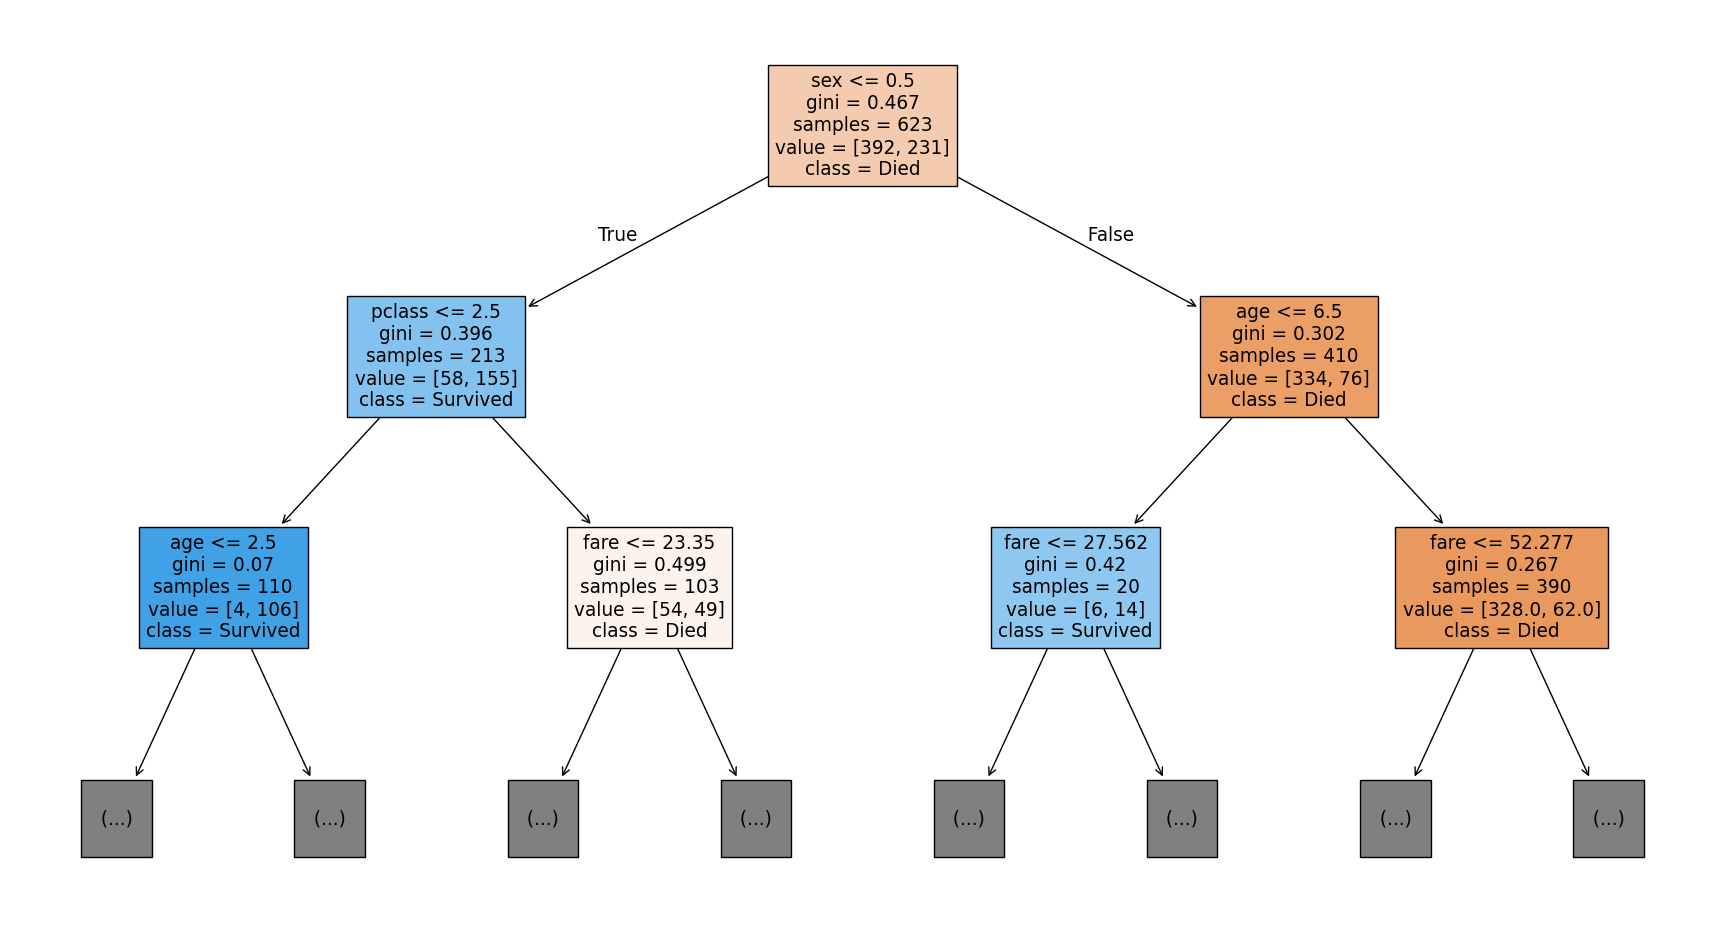

In [29]:
## Ploting Tree 
from sklearn.tree import plot_tree
plt.figure(figsize=(22,12))
plot_tree(
     model,
     feature_names=X.columns,
     class_names=["Died","Survived"],
     filled=True,
     max_depth=2
)

- Decision Tree With Preprunning (suitable for small dataset problem)

for depth:2 & accuracy:0.7723880597014925
for depth:3 & accuracy:0.8059701492537313
for depth:4 & accuracy:0.8246268656716418
for depth:5 & accuracy:0.7947761194029851
for depth:6 & accuracy:0.7873134328358209
for depth:7 & accuracy:0.7761194029850746
for depth:8 & accuracy:0.7947761194029851
for depth:9 & accuracy:0.7761194029850746
for depth:10 & accuracy:0.7873134328358209


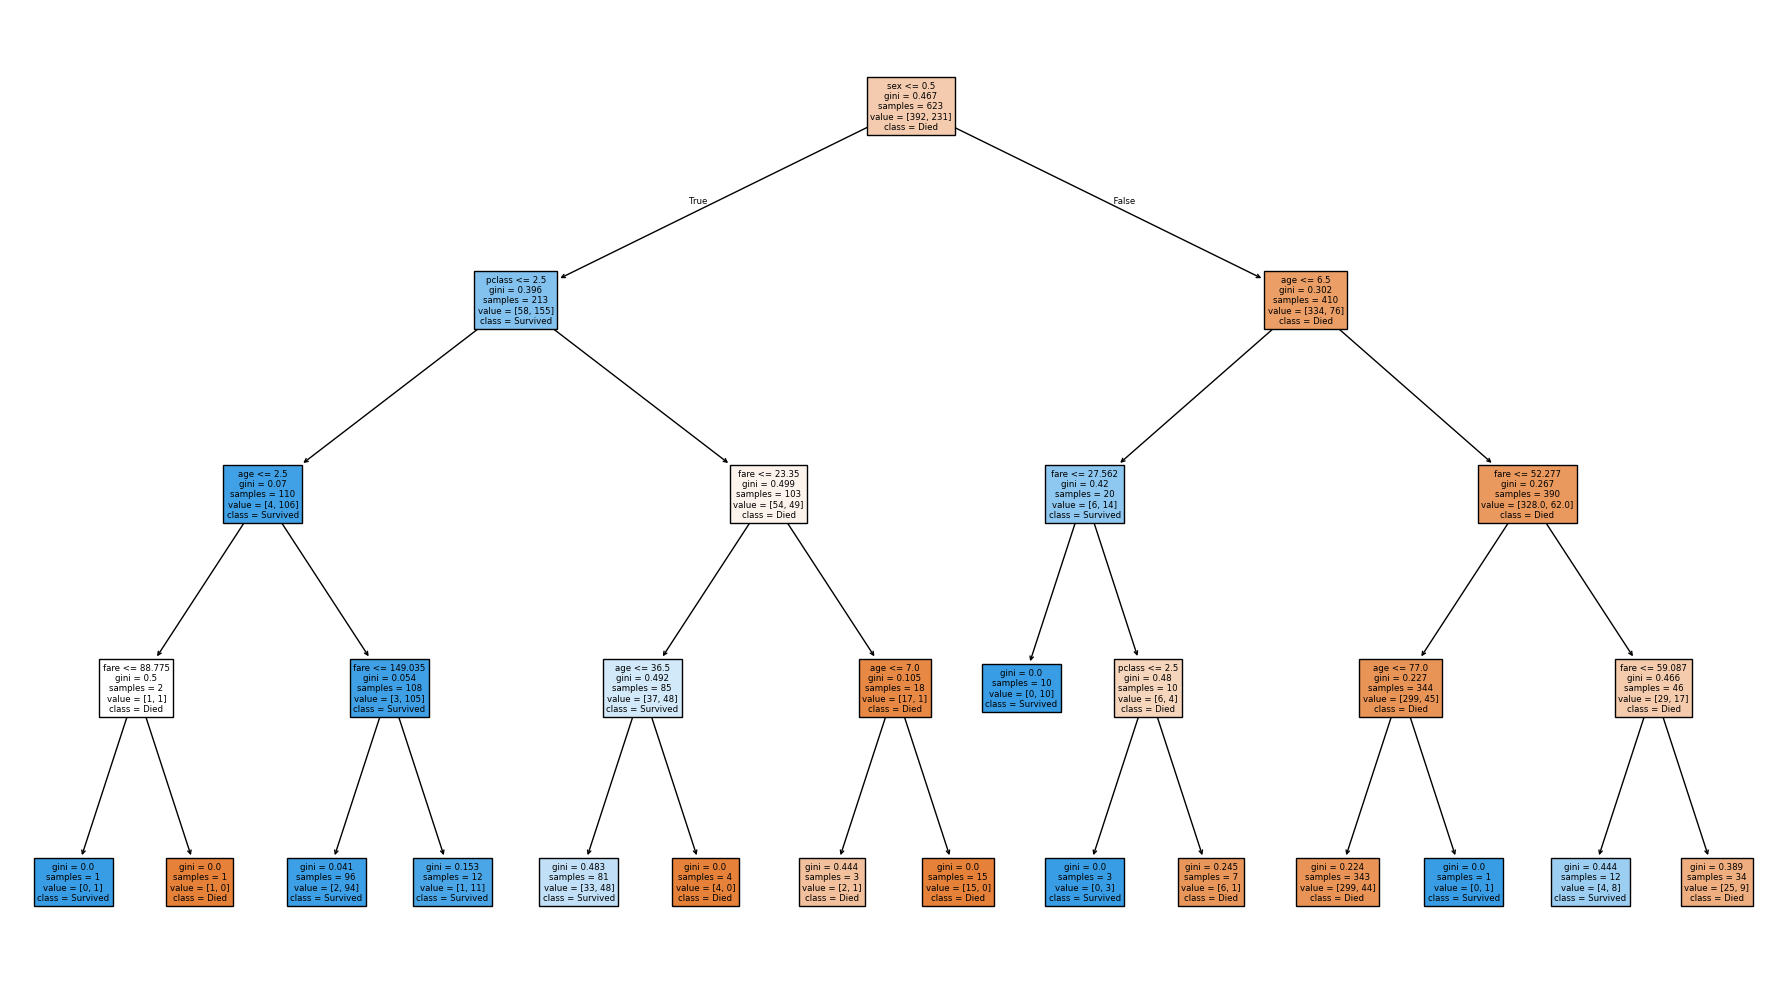

In [30]:
max_depth = [2,3,4,5,6,7,8,9,10]

for depth in max_depth:
     model = DecisionTreeClassifier(max_depth=depth)
     model.fit(X_train,y_train)

     acc = model.score(X_test,y_test)
     print(f"for depth:{depth} & accuracy:{acc}")

     if depth == 4:
          plt.figure(figsize=(18,10))
          plot_tree(
          model,
          feature_names=X.columns,
          class_names = ["Died","Survived"],
          filled=True,
)

plt.tight_layout()
plt.show()

for depth:10 & accuracy:0.8246268656716418
for depth:20 & accuracy:0.8171641791044776
for depth:30 & accuracy:0.8208955223880597
for depth:40 & accuracy:0.8208955223880597
for depth:50 & accuracy:0.8134328358208955
for depth:70 & accuracy:0.8134328358208955
for depth:100 & accuracy:0.8097014925373134


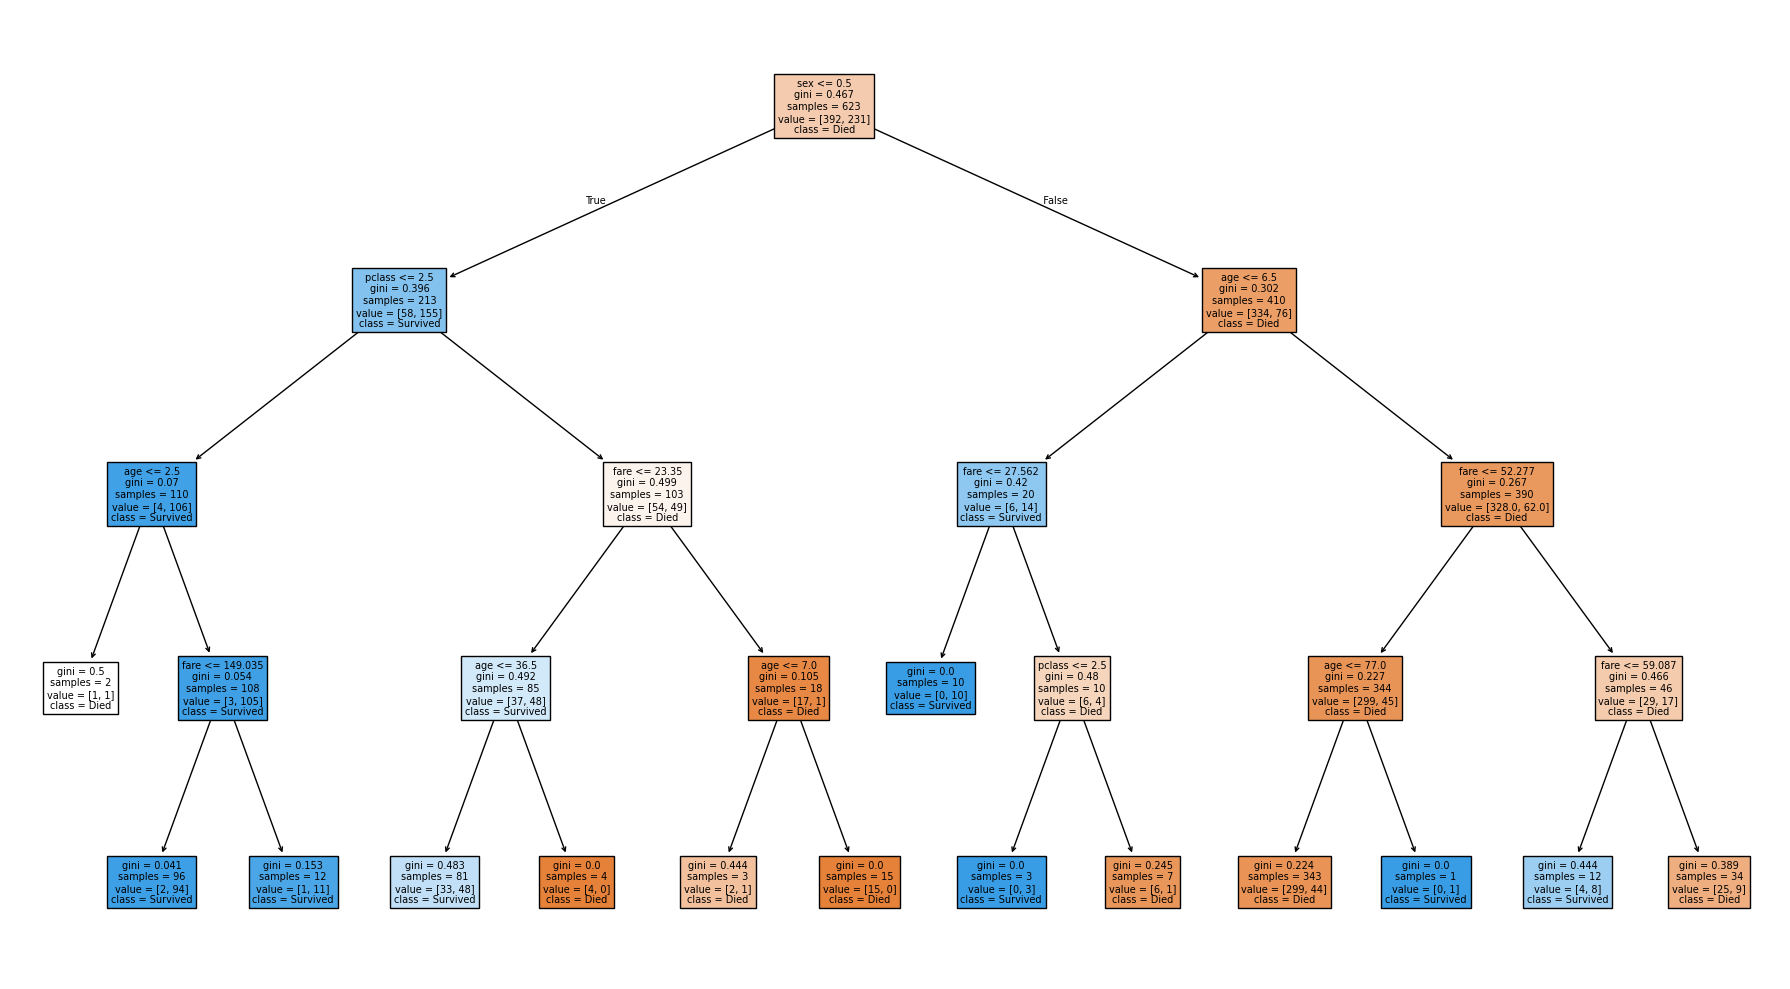

In [32]:
min_split = [10,20,30,40,50,70,100]

for split in min_split:
     model = DecisionTreeClassifier(max_depth=4,min_samples_split=split)
     model.fit(X_train,y_train)

     acc = model.score(X_test,y_test)
     print(f"for depth:{split} & accuracy:{acc}")

     if split == 10:
          plt.figure(figsize=(18,10))
          plot_tree(
          model,
          feature_names=X.columns,
          class_names = ["Died","Survived"],
          filled=True,
)

plt.tight_layout()
plt.show()

- Decision Tree With Post Prunning (suitable for large datasets)

In [33]:
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [37]:
path = tree.cost_complexity_pruning_path(X_train,y_train)

ccp_alphas = path.ccp_alphas
impurities = path.impurities

print(ccp_alphas)

[0.         0.         0.00013376 0.00013376 0.00022931 0.00032103
 0.00048409 0.00053505 0.00053505 0.00053505 0.00062746 0.00064205
 0.00077709 0.00085607 0.00093633 0.00096308 0.00096308 0.00096308
 0.00099875 0.00101659 0.00104193 0.0010478  0.00107009 0.00109238
 0.00115927 0.0012352  0.00123729 0.00129646 0.00132211 0.00133563
 0.00137583 0.00137583 0.00139708 0.00143228 0.00144145 0.00150482
 0.00151596 0.00152184 0.00171215 0.00183444 0.0019012  0.00195674
 0.00200642 0.00214018 0.00233474 0.0024077  0.00260835 0.00263292
 0.00278606 0.00280169 0.00284379 0.00288925 0.00299625 0.00302412
 0.00431144 0.00495299 0.00577849 0.00589431 0.0074248  0.01236198
 0.01787674 0.04065074 0.1323581 ]


In [43]:
## Train Our Model For All Alphas 
tree = []
for alpha in ccp_alphas:
    model = DecisionTreeClassifier(
        random_state=42,
        ccp_alpha=alpha
    )    
    model.fit(X_train, y_train)
    tree.append((model, alpha))

best_acc = 0
best_alpha = 0

for model,alpha in tree:
     curr_acc = model.score(X_test,y_test)
     if curr_acc > best_acc:
          best_acc = curr_acc
          best_alpha = alpha

In [49]:
print(best_acc,best_alpha)

0.8208955223880597 0.0017121455323702516


In [51]:
best_model = DecisionTreeClassifier(
     random_state=42,
     ccp_alpha=best_alpha,
     max_depth=4
)
best_model.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

[Text(0.3472222222222222, 0.9, 'sex <= 0.5\ngini = 0.467\nsamples = 623\nvalue = [392, 231]\nclass = Died'),
 Text(0.1111111111111111, 0.7, 'pclass <= 2.5\ngini = 0.396\nsamples = 213\nvalue = [58, 155]\nclass = Survived'),
 Text(0.22916666666666666, 0.8, 'True  '),
 Text(0.05555555555555555, 0.5, 'gini = 0.07\nsamples = 110\nvalue = [4, 106]\nclass = Survived'),
 Text(0.16666666666666666, 0.5, 'fare <= 23.35\ngini = 0.499\nsamples = 103\nvalue = [54, 49]\nclass = Died'),
 Text(0.1111111111111111, 0.3, 'age <= 36.5\ngini = 0.492\nsamples = 85\nvalue = [37, 48]\nclass = Survived'),
 Text(0.05555555555555555, 0.1, 'gini = 0.483\nsamples = 81\nvalue = [33, 48]\nclass = Survived'),
 Text(0.16666666666666666, 0.1, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]\nclass = Died'),
 Text(0.2222222222222222, 0.3, 'gini = 0.105\nsamples = 18\nvalue = [17, 1]\nclass = Died'),
 Text(0.5833333333333334, 0.7, 'age <= 6.5\ngini = 0.302\nsamples = 410\nvalue = [334, 76]\nclass = Died'),
 Text(0.46527777777777

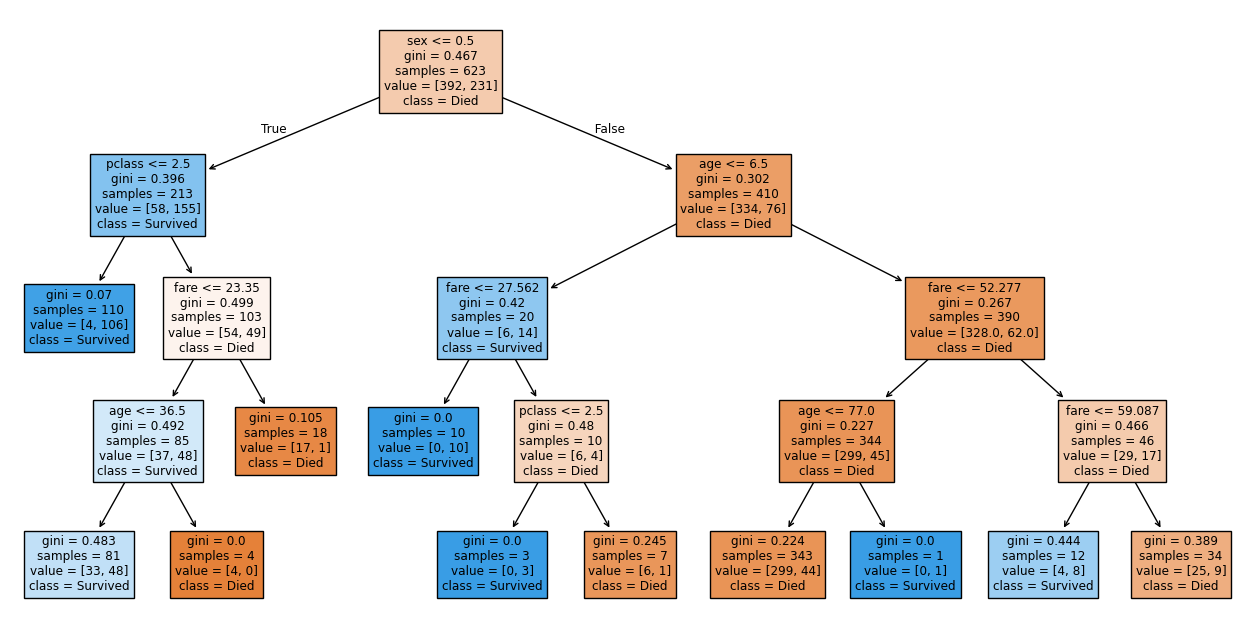

In [54]:
plt.figure(figsize=(16,8))
plot_tree(
     best_model,
     feature_names=X.columns,
     class_names=["Died","Survived"],
     filled=True
)

In [56]:
print(best_model.score(X_test,y_test))

0.8246268656716418


In [57]:
## Decision Tree For Regression
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

df = load_diabetes(as_frame=True).frame

In [58]:
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [59]:
df.isnull().sum()

age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

In [60]:
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.268604e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [62]:
df.nunique()

age        58
sex         2
bmi       163
bp        100
s1        141
s2        302
s3         63
s4         66
s5        184
s6         56
target    214
dtype: int64

In [63]:
df.shape

(442, 11)

In [65]:
X = df.drop("target",axis=1)
y = df["target"]

## Train Test Split
X_train,X_test,y_train,y_test = train_test_split(
     X,y,test_size=0.3,random_state=42
)

In [66]:
X_train.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
225,0.030811,0.050680,0.032595,0.049415,-0.040096,-0.043589,-0.069172,0.034309,0.063015,0.003064
412,0.074401,-0.044642,0.085408,0.063187,0.014942,0.013091,0.015505,-0.002592,0.006207,0.085907
118,-0.056370,0.050680,-0.010517,0.025315,0.023198,0.040022,-0.039719,0.034309,0.020609,0.056912
114,0.023546,-0.044642,0.110198,0.063187,0.013567,-0.032942,-0.024993,0.020655,0.099241,0.023775
364,0.001751,0.050680,-0.006206,-0.019442,-0.009825,0.004949,-0.039719,0.034309,0.014821,0.098333


In [67]:
X_test.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
287,0.045341,-0.044642,-0.006206,-0.015999,0.125019,0.125198,0.019187,0.034309,0.032432,-0.005220
211,0.092564,-0.044642,0.036907,0.021872,-0.024960,-0.016658,0.000779,-0.039493,-0.022517,-0.021788
72,0.063504,0.050680,-0.004050,-0.012556,0.103003,0.048790,0.056003,-0.002592,0.084492,-0.017646
321,0.096197,-0.044642,0.051996,0.079265,0.054845,0.036577,-0.076536,0.141322,0.098648,0.061054
73,0.012648,0.050680,-0.020218,-0.002228,0.038334,0.053174,-0.006584,0.034309,-0.005142,-0.009362


In [68]:
## Train Our Model
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor(max_depth=5,min_samples_split=30)
model.fit(X_train,y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",30
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_l

In [78]:
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

In [ ]:
from sklearn.metrics import r2_score,mean_squared_error


print("MSE Train:",
      mean_squared_error(y_train, y_pred_train))

print("R^2 Train:",
      r2_score(y_train, y_pred_train))


print("MSE Test:",
      mean_squared_error(y_test, y_pred_test))

print("R^2 Test:",
      r2_score(y_test, y_pred_test))
## Overfit Model

MSE Train: 2299.470633269066
R^2 Train: 0.6259978487422528
MSE Test: 3740.8813326340146
R^2 Test: 0.30702703557473265


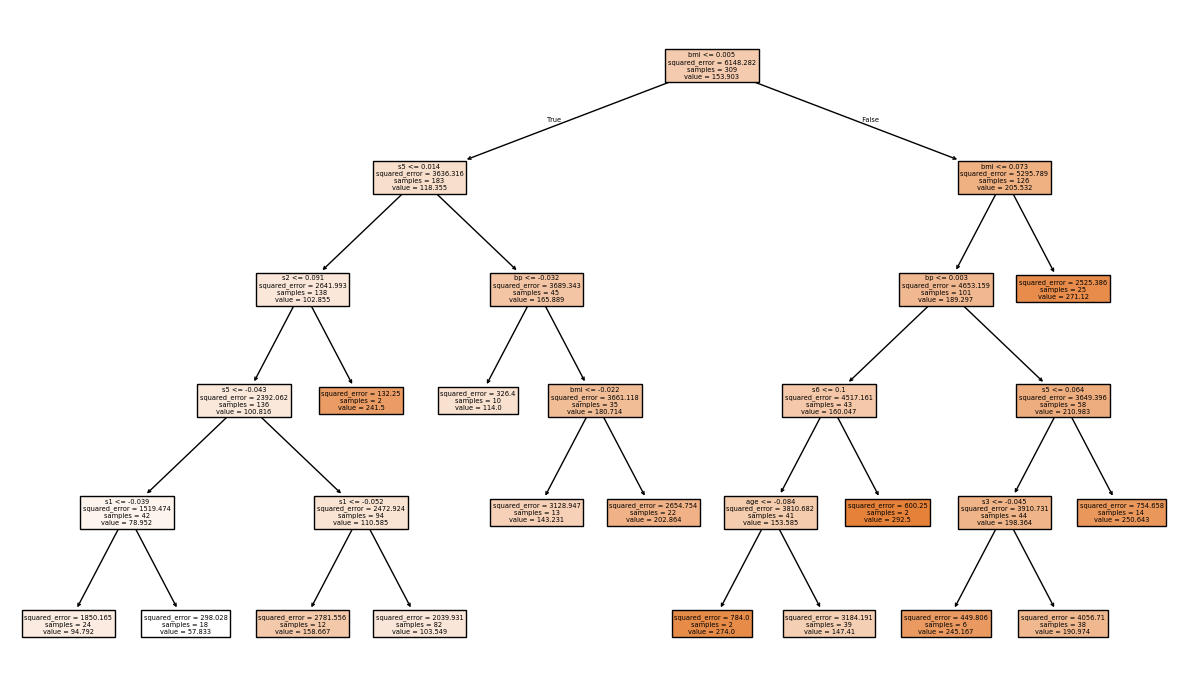

In [76]:
from sklearn.tree import plot_tree

plt.figure(figsize=(12,7))
plot_tree(
     model,
     feature_names=X.columns,
     filled=True
)
plt.tight_layout()

***
- Ensemble Techniques
    - Bagging
    - Boosting


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,precision_score

titanic = sns.load_dataset("titanic")

features = ["pclass", "sex", "fare", "embarked", "age"]
target = ["survived"]

# handle missing data
imp_median = SimpleImputer(strategy="median")
titanic[["age"]] = imp_median.fit_transform(titanic[["age"]])

imp_freq = SimpleImputer(strategy="most_frequent")
titanic[["embarked"]] = imp_freq.fit_transform(titanic[["embarked"]])

# encode
le = LabelEncoder()

titanic["sex"] = le.fit_transform(titanic["sex"])
titanic["embarked"] = le.fit_transform(titanic["embarked"])

X = titanic[features]
y = titanic["survived"]

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.3, random_state=42
)

- Random Forest For Classiifcation

In [80]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(
     n_estimators=1001,
     oob_score=True,
     max_depth=4
)

rf_clf.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1001
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [82]:
y_pred = rf_clf.predict(X_test)

print(f"OOB score: {rf_clf.oob_score_ * 100}%")
print(f"testing accuracy: {accuracy_score(y_test, y_pred) * 100}%")

OOB score: 82.34349919743178%
testing accuracy: 81.34328358208955%


- Bagging Classifier (Base Model --> Decision Tree)
- Bagging Regressor (Base Model --> Logistic Regression)

In [83]:
## Bagging Classiifer
from sklearn.ensemble import BaggingClassifier
base_model = DecisionTreeClassifier()
bagging = BaggingClassifier(
     base_model,
     n_estimators=201
)
bagging.fit(X_train,y_train)

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeClassifier()
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",201
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",None
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary `... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [86]:
y_pred = bagging.predict(X_test)
print(f"accuracy score: {accuracy_score(y_test,y_pred)*100}%")
y_pred = bagging.predict(X_test)
print(f"precision score: {precision_score(y_test,y_pred)*100}%")

accuracy score: 77.61194029850746%
precision score: 72.97297297297297%


In [87]:
## Bagging Regressor
from sklearn.ensemble import BaggingClassifier
from sklearn.linear_model import LogisticRegression
base_model = LogisticRegression()
bagging = BaggingClassifier(
     base_model,
     n_estimators=301
)
bagging.fit(X_train,y_train)

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",LogisticRegression()
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",301
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",None
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary `... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [88]:
y_pred = bagging.predict(X_test)
print(f"accuracy score: {accuracy_score(y_test,y_pred)*100}%")
y_pred = bagging.predict(X_test)
print(f"precision score: {precision_score(y_test,y_pred)*100}%")

accuracy score: 79.47761194029852%
precision score: 75.92592592592592%


***
- **Gradient Boosting** 
   - Classification Problem
   - Regression Problem

In [12]:
## For Regression 
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_squared_error
from sklearn.datasets import make_regression

## Generating Data
X,y = make_regression(
     n_samples=5000,
     n_features=12,
     noise=21,
     random_state=42
)

## Train Test Split
X_train,X_test,y_train,y_test = train_test_split(
     X,y,test_size=0.3,random_state=42
)

In [13]:
X_train

array([[ 0.3384878 ,  0.38090883,  0.83476243, ...,  0.16923956,
        -1.10306465, -0.42028207],
       [-0.94346982,  0.80112858, -0.38705303, ...,  1.7097059 ,
         0.87316929, -0.15935857],
       [ 0.18482703,  0.34739749,  0.23764266, ..., -0.98800282,
         0.55982845,  1.84181561],
       ...,
       [-0.54502757, -1.30479377,  1.90801085, ..., -0.8991961 ,
         1.40430551, -1.18303067],
       [-0.03597999, -0.17200515,  0.28133855, ..., -0.65471497,
        -0.9580588 , -0.0963426 ],
       [ 0.75968825,  0.42914152, -0.27489638, ..., -1.51744036,
         1.59901933, -0.15536697]], shape=(3500, 12))

In [14]:
from sklearn.ensemble import GradientBoostingRegressor
gbr = GradientBoostingRegressor(
     n_estimators=301,
     learning_rate=0.02,
     random_state=42,
     max_depth=3,
     subsample=0.7
)
gbr.fit(X_train,y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.02
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",301
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",0.7
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft

In [ ]:
## Evaluation Metrics
y_pred = gbr.predict(X_test)
print(f"R_Squarred: {r2_score(y_test,y_pred)*100}%")
print(f"Mean Squarred Error: {mean_squared_error(y_test,y_pred)}")

R_Squarred: 88.36777538940154%
Mean Squarred Error: 4796.395275498238


In [17]:
## For Classification
from sklearn.datasets import make_classification
X,y = make_classification(
     n_samples=7900,
     n_features=21,
     n_informative=9,
     random_state=42
)

## Train Test Split
X_train,X_test,y_train,y_test = train_test_split(
     X,y,random_state=42,test_size=0.3
)

In [18]:
X_train

array([[-4.31305014,  0.41947445,  4.90053064, ...,  5.03914375,
        -1.24389796,  0.05744809],
       [-2.42435825, -0.38646762, -0.73236872, ...,  2.85165863,
        -3.45662054, -0.07215996],
       [ 0.33073463,  1.06143883, -1.64899592, ...,  1.56578541,
         0.9207888 , -0.2016698 ],
       ...,
       [ 5.00009913, -0.83502999,  2.1961398 , ..., -1.29852695,
         3.09713475, -1.27660208],
       [ 8.2618427 ,  1.52484319, -0.22365311, ...,  2.61393588,
         3.05453011,  0.7883469 ],
       [ 2.94570744, -2.06386387,  3.33777458, ..., -2.27496438,
         1.5197977 ,  1.27782137]], shape=(5530, 21))

In [19]:
## Model Training
from sklearn.ensemble import GradientBoostingClassifier
gbc = GradientBoostingClassifier(
     learning_rate=0.005,
     n_estimators=201,
     max_depth=3,
     random_state=42
)
gbc.fit(X_train,y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.005
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",201
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``

In [21]:
## Evaluation Metrics
from sklearn.metrics import accuracy_score,precision_score,classification_report
y_pred = gbc.predict(X_test)
print(f"Accuracy Score:{accuracy_score(y_test,y_pred)*100}%")
print(f"Precision Score:{precision_score(y_test,y_pred)*100}%")

Accuracy Score:83.16455696202532%
Precision Score:81.12764291307752%


In [22]:
print(f"Classification Report:{classification_report(y_test,y_pred)}")

Classification Report:              precision    recall  f1-score   support

           0       0.86      0.80      0.82      1176
           1       0.81      0.87      0.84      1194

    accuracy                           0.83      2370
   macro avg       0.83      0.83      0.83      2370
weighted avg       0.83      0.83      0.83      2370



***
- **LightBGM**
   - Classification
   - Regression

- Interview Specific Answer
  - LightGBM is an optimized gradient boosting framework that builds trees using a leaf-wise strategy instead of traditional level-wise growth. It uses histogram-based splitting and parallel processing to improve speed and efficiency. For regression, it minimizes squared error, and for classification, it minimizes log loss. It performs exceptionally well on large structured datasets.

In [36]:
!pip install lightgbm

In [61]:
import lightgbm as lgb
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create model
model = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    num_leaves=31,
    max_depth=-1
)

# Train model
model.fit(X_train, y_train)


[LightGBM] [Info] Number of positive: 286, number of negative: 169
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000249 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4548
[LightGBM] [Info] Number of data points in the train set: 455, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.628571 -> initscore=0.526093
[LightGBM] [Info] Start training from score 0.526093
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [62]:
# Predictions
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9649122807017544


c:\Users\gzbra\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [63]:
## For REgression
import lightgbm as lgb
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Load dataset
data = fetch_california_housing()
X = data.data
y = data.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create model
model = lgb.LGBMRegressor(
    n_estimators=100,
    learning_rate=0.1,
    num_leaves=31
)

# Train model
model.fit(X_train, y_train)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001571 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1838
[LightGBM] [Info] Number of data points in the train set: 16512, number of used features: 8
[LightGBM] [Info] Start training from score 2.071947


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [64]:
# Predictions
y_pred = model.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 0.21484820209255617


c:\Users\gzbra\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


***
- **Ada Boost**
  - Classification
  - Regression

In [27]:
## For Classifciation
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,classification_report
from sklearn.tree import DecisionTreeClassifier

## Generating Datasets
X,y = make_classification(
     n_samples=8999,
     n_features=21,
     n_informative=11,
     n_redundant=3,
     random_state=42
)

## Train Test Split
X_train,X_test,y_train,y_test = train_test_split(
     X,y,test_size=0.3,random_state=42
)

In [28]:
## Model Training
from sklearn.ensemble import AdaBoostClassifier

## DT Stump
base_model = DecisionTreeClassifier(
     max_depth=1
)
adb_clf = AdaBoostClassifier(
     estimator=base_model,
     n_estimators=301,
     random_state=42
)
adb_clf.fit(X_train,y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeC...r(max_depth=1)
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",301
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None


In [30]:
y_pred = adb_clf.predict(X_test)

## Evaluation Metrics
print(f" Accuracy Score: {accuracy_score(y_test,y_pred)*100}%")
print(f" Precision Score: {precision_score(y_test,y_pred)*100}%")

 Accuracy Score: 82.77777777777777%
 Precision Score: 80.81603435934144%


In [31]:
print(f"classification report:{classification_report(y_test,y_pred)}")

classification report:              precision    recall  f1-score   support

           0       0.85      0.80      0.83      1374
           1       0.81      0.85      0.83      1326

    accuracy                           0.83      2700
   macro avg       0.83      0.83      0.83      2700
weighted avg       0.83      0.83      0.83      2700



In [32]:
## For Regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
from sklearn.datasets import make_regression
import numpy as np

## Generating Datasets
X,y = make_regression(
     n_samples=9999,
     n_features=11,
     noise=20,
     random_state=42
)

## Train Test Split
X_train,X_test,y_train,y_test  = train_test_split(
     X,y,random_state=42,test_size=0.3  
)

In [33]:
X_train

array([[-0.23259924, -0.5397268 ,  0.24551844, ...,  2.97985452,
         0.14240487,  0.38827425],
       [-1.72705753,  0.07045959,  0.99115313, ...,  0.16088895,
         0.65463102, -0.41799223],
       [-0.23586432, -0.33261079,  1.00589192, ..., -0.43342084,
        -0.29237504, -0.20886709],
       ...,
       [-0.37883932,  0.49694808, -0.81530973, ...,  0.43348428,
        -0.49313566, -1.75454648],
       [-1.79784362, -0.33626469, -0.28047204, ...,  1.01782188,
        -1.03613113, -0.7117799 ],
       [-1.96196685,  1.56819969, -1.5477064 , ...,  0.33167396,
         0.3482211 , -0.02995465]], shape=(6999, 11))

In [35]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor

## DT Stump
base_model = DecisionTreeRegressor(
     max_depth=1
)
## Moedel Training
adb_reg = AdaBoostRegressor(
     estimator=base_model,
     n_estimators=101,
     random_state=42
)
adb_reg.fit(X_train,y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.If ``None``, then the base estimator is:class:`~sklearn.tree.DecisionTreeRegressor` initialized with`max_depth=3`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeR...r(max_depth=1)
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",101
,"learning_rate learning_rate: float, default=1.0Weight applied to each regressor at each boosting iteration. A higherlearning rate increases the contribution of each regressor. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"loss loss: {'linear', 'square', 'exponential'}, default='linear'The loss function to use when updating the weights after eachboosting iteration.",'linear'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.In addition, it controls the bootstrap of the weights used to train the`estimator` at each boosting iteration.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provid

In [36]:
y_pred = adb_reg.predict(X_test)

## Evaluation Metrics
print(f"R2 Square: {r2_score(y_test,y_pred)*100}%")
print(f"MAE: {mean_absolute_error(y_test, y_pred)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}")

R2 Square: 59.76189186150697%
MAE: 90.38923799595408
RMSE: 112.21284731320455


***
- **XgBoost**
   - Classification
   - Regression

- Interview Specific Answer
   - XGBoost is an advanced implementation of Gradient Boosting that builds decision trees sequentially. It improves traditional boosting by using both first and second order derivatives for optimization and adds regularization to prevent overfitting. It also supports parallel processing and efficient tree pruning, which makes it faster and more accurate than standard Gradient Boosting.

In [38]:
!pip install xgboost

In [39]:
## For Classification Problem
import xgboost as xgb
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,classification_report

## Generating Data
X,y = make_classification(
     n_samples=7877,
     n_features=21,
     n_redundant=3,
     n_informative=11,
     random_state=42
)

## Train Test Split
X_train,X_test,y_train,y_test = train_test_split(
     X,y,random_state=42,test_size=0.3
)

In [40]:
X_train

array([[-1.2799751 ,  0.87531995, -1.43709637, ...,  1.52741282,
         2.11986308, -0.60504438],
       [-0.22138566, -0.17834262,  6.28727009, ..., -0.45901419,
         0.23665638,  1.10825053],
       [ 0.67733694, -0.11629172,  0.59757933, ..., -0.58275217,
         0.77950349, -1.69078619],
       ...,
       [-1.15761973,  2.39319518,  8.83311084, ..., -7.29684621,
         0.96529857,  3.78772778],
       [-0.04931792,  0.27119201, -4.80424924, ...,  1.29011893,
        -0.04562676, -1.27208963],
       [-0.3509776 ,  1.84799242,  6.08039931, ...,  3.50540783,
        -0.15764336, -0.85537564]], shape=(5513, 21))

In [42]:
## Model Training
xgb_clf = xgb.XGBClassifier(
     n_estimators=201,
     max_depth=3,
     learning_rate=0.01,
     eval_metrics="logloss",
     random_state = 42
)
xgb_clf.fit(X_train,y_train)

c:\Users\gzbra\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:12:01] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "eval_metrics" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [43]:
y_pred = xgb_clf.predict(X_test)

## Evaluation Metrics
print(f"Accuracy Score: {accuracy_score(y_test,y_pred)*100}%")
print(f"Precision Score: {precision_score(y_test,y_pred)*100}%")

Accuracy Score: 86.75972927241963%
Precision Score: 86.85567010309279%


In [44]:
print(f"classification report:{classification_report(y_test,y_pred)}")

classification report:              precision    recall  f1-score   support

           0       0.87      0.87      0.87      1193
           1       0.87      0.86      0.87      1171

    accuracy                           0.87      2364
   macro avg       0.87      0.87      0.87      2364
weighted avg       0.87      0.87      0.87      2364



In [45]:
## XgBoost For Regression Problem
import xgboost as xgb
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
import numpy as np

## Generating Data
X,Y = make_regression(
     n_samples=9000,
     n_features=11,
     noise=21,
     random_state=42
)

X_train,X_test,y_train,y_test = train_test_split(
     X,Y,test_size=0.3,random_state=42
)

In [48]:
## Model Training
xgb_reg = xgb.XGBRegressor(
     n_estimators=201,
     objective="reg:squarederror",
     eval_metrics="rmse",
     random_state=42
)
xgb_reg.fit(X_train,y_train)

c:\Users\gzbra\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:18:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "eval_metrics" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_met

In [50]:
y_pred = xgb_reg.predict(X_test)

## Evaluation Metrics
print(f"R2_Score: {r2_score(y_test,y_pred)*100}%")
print(f"MAE: {mean_absolute_error(y_test,y_pred)*100}%")
print(f"RMSE:{np.sqrt(mean_squared_error(y_test,y_pred))}")

R2_Score: 94.6901942293893%
MAE: 3360.7152628181107%
RMSE:42.34666157204845


***
- **CatBoost** (unstable for python 14 version)
   - Regression 
   - Classification

- Interview Specific Answer
   - CatBoost is an advanced gradient boosting algorithm that efficiently handles categorical variables using ordered boosting and reduces overfitting. It works well for both classification and regression tasks on structured data.
   
***OR***

   - CatBoost can directly handle categorical features using ordered target encoding, which prevents data leakage and reduces preprocessing complexity compared to other boosting algorithms.

In [ ]:
## For Classification 
from catboost import CatBoostClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd

# Load dataset
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create model
model = CatBoostClassifier(
    iterations=100,
    learning_rate=0.1,
    depth=6,
    verbose=0   # training output hide karne ke liye
)

# Train
model.fit(X_train, y_train)

In [ ]:
# Predict
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

In [ ]:
## For Regression
from catboost import CatBoostClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd

# Load dataset
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create model
model = CatBoostClassifier(
    iterations=100,
    learning_rate=0.1,
    depth=6,
    verbose=0   # training output hide karne ke liye
)

# Train
model.fit(X_train, y_train)


In [ ]:
# Predict
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

***
- **Support Vector Machine**
   - Support Vector Classifier (SVC)
   - Supprt Vector Regressor (SVR)

- Interview Specific Answer
   - Support Vector Machine is a supervised learning algorithm that finds the optimal hyperplane with maximum margin between classes in classification problems. It relies only on support vectors, which are the closest data points to the boundary. In regression, it fits a function within a margin called epsilon and penalizes only large deviations. Kernel functions allow SVM to handle non-linear data efficiently.

In [ ]:
## Classification Problem
from sklearn.svm import SVC
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn import datasets

df = datasets.load_iris(as_frame=True).frame
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [52]:
df.shape

(150, 5)

In [53]:
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [55]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [56]:
X = df.drop("target",axis=1)
y = df["target"]

## Train Test Split
X_train,X_test,y_train,y_test = train_test_split(
     X,y,test_size=0.3,random_state=42,stratify=y
)

In [57]:
## Scale Our Data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [58]:
## Model
svc = SVC()
svc.fit(X_train_scaled,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [61]:
y_pred = svc.predict(X_test_scaled)

## Evaluation Metrics
from sklearn.metrics import accuracy_score,classification_report,f1_score
print("accuracy:",accuracy_score(y_test,y_pred))

accuracy: 0.9333333333333333


In [62]:
print("classification report:",classification_report(y_test,y_pred))

classification report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.88      0.93      0.90        15
           2       0.93      0.87      0.90        15

    accuracy                           0.93        45
   macro avg       0.93      0.93      0.93        45
weighted avg       0.93      0.93      0.93        45



In [63]:
f1 = f1_score(y_test, y_pred, average='weighted')
print("F1 Score:", f1)

F1 Score: 0.9332591768631814


In [65]:
## Multiple Model Check

## Linear Kernel
svc = SVC(kernel="linear")
svc.fit(X_train_scaled,y_train)

y_pred = svc.predict(X_test_scaled)
print("accuracy score using linear kernel:",accuracy_score(y_test,y_pred))


## Polynomial Kernel
svc = SVC(kernel="poly")
svc.fit(X_train_scaled,y_train)

y_pred = svc.predict(X_test_scaled)
print("accuracy score using polynomial kerenl :",accuracy_score(y_test,y_pred))

## Sigmoid Kernel
svc = SVC(kernel="sigmoid")
svc.fit(X_train_scaled,y_train)

y_pred = svc.predict(X_test_scaled)
print("accuracy score using sigmoid kernel:",accuracy_score(y_test,y_pred))

accuracy score using linear kernel: 0.9111111111111111
accuracy score using polynomial kerenl : 0.8666666666666667
accuracy score using sigmoid kernel: 0.9111111111111111


In [66]:
c_vals = [0.5,1,2,3,4,5]

for val in c_vals:
     svc = SVC(C=val,kernel="rbf")
     svc.fit(X_train_scaled,y_train)

     y_pred = svc.predict(X_test_scaled)
     print(f"C: {val} & accuracy: {accuracy_score(y_test,y_pred)}")


C: 0.5 & accuracy: 0.9111111111111111
C: 1 & accuracy: 0.9333333333333333
C: 2 & accuracy: 0.9111111111111111
C: 3 & accuracy: 0.9111111111111111
C: 4 & accuracy: 0.9333333333333333
C: 5 & accuracy: 0.9333333333333333


In [6]:
## Regression Problem
from sklearn.svm import SVR
import pandas as pd
from sklearn import datasets

In [7]:
df = datasets.load_diabetes(as_frame=True).frame
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [8]:
df.shape

(442, 11)

In [9]:
df.isnull().sum()

age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

In [11]:
X = df.drop("target",axis=1)
y = df["target"]

## Train Test Split
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
     X,y,random_state=42,test_size=0.3
)
X_train.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
225,0.030811,0.050680,0.032595,0.049415,-0.040096,-0.043589,-0.069172,0.034309,0.063015,0.003064
412,0.074401,-0.044642,0.085408,0.063187,0.014942,0.013091,0.015505,-0.002592,0.006207,0.085907
118,-0.056370,0.050680,-0.010517,0.025315,0.023198,0.040022,-0.039719,0.034309,0.020609,0.056912
114,0.023546,-0.044642,0.110198,0.063187,0.013567,-0.032942,-0.024993,0.020655,0.099241,0.023775
364,0.001751,0.050680,-0.006206,-0.019442,-0.009825,0.004949,-0.039719,0.034309,0.014821,0.098333


In [12]:
y_train.head()

225    208.0
412    261.0
118    179.0
114    258.0
364    262.0
Name: target, dtype: float64

In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score,mean_squared_error

## Scaling Y Values
y_scale = StandardScaler()
y_train_scaled = y_scale.fit_transform(y_train.values.reshape(-1,1)).ravel()
y_test_scaled = y_scale.fit_transform(y_test.values.reshape(-1,1)).ravel()

In [16]:
y_train_scaled

array([ 6.89917243e-01,  1.36584298e+00,  3.20071083e-01,  1.32758304e+00,
        1.37859630e+00, -1.31235335e+00,  1.05976340e+00, -1.05728703e+00,
       -1.90061552e-01,  1.45511620e+00, -1.08279366e+00,  2.08002867e+00,
        1.21280319e+00,  1.23818601e-03,  4.85864189e-01, -4.83387817e-01,
       -9.29753873e-01, -4.06867922e-01,  1.34033635e+00,  4.73110873e-01,
        1.76119578e+00, -1.26134009e+00, -5.98167660e-01,  7.15423875e-01,
       -8.02220714e-01,  1.26381646e+00, -8.78740609e-01,  1.25106314e+00,
       -1.21032682e+00, -9.68013820e-01,  5.87890716e-01, -9.68013820e-01,
        1.16178993e+00,  2.69057819e-01, -1.42713319e+00, -3.43101343e-01,
       -1.28684672e+00, -7.63960766e-01, -6.36427608e-01,  5.75137400e-01,
        1.41685625e+00,  1.62090930e+00,  1.20004988e+00,  1.31482972e+00,
        7.79190454e-01,  1.90148225e+00,  2.05291240e-01, -1.21032682e+00,
        1.56989604e+00,  7.02670559e-01, -2.02814868e-01,  5.62384084e-01,
       -3.81361290e-01, -

In [17]:
## Model Training
model = SVR()
model.fit(X_train,y_train_scaled)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [21]:
y_pred_test = model.predict(X_test)
y_pred_train = model.predict(X_train)

## Evaluation Metrics
print("Train r2: ",r2_score(y_train_scaled,y_pred_train))
print("Test r2: ",r2_score(y_test_scaled,y_pred_test))

Train r2:  0.6596361676267714
Test r2:  0.4808287850481273


In [22]:
## Linear Kernel
model = SVR(kernel="linear")
model.fit(X_train,y_train_scaled)

y_test_pred_scaled = model.predict(X_test)
y_train_pred_scaled = model.predict(X_train)

print("Train r2: ",r2_score(y_train_scaled,y_train_pred_scaled))
print("Test r2: ",r2_score(y_test_scaled,y_test_pred_scaled))

Train r2:  0.45191229982475256
Test r2:  0.41295430606006556


In [23]:
## Polynomial Kernel (overfitting)
model = SVR(kernel="poly")
model.fit(X_train,y_train_scaled)

y_test_pred_scaled = model.predict(X_test)
y_train_pred_scaled = model.predict(X_train)

print("Train r2: ",r2_score(y_train_scaled,y_train_pred_scaled))
print("Test r2: ",r2_score(y_test_scaled,y_test_pred_scaled))

Train r2:  0.5790920834310542
Test r2:  0.2496489598680388


In [24]:
## Sigmoid Kernel (Not Good For Used)
model = SVR(kernel="sigmoid")
model.fit(X_train,y_train_scaled)

y_test_pred_scaled = model.predict(X_test)
y_train_pred_scaled = model.predict(X_train)

print("Train r2: ",r2_score(y_train_scaled,y_train_pred_scaled))
print("Test r2: ",r2_score(y_test_scaled,y_test_pred_scaled))

Train r2:  -19.721193440731312
Test r2:  -13.334780649499326


- Hyperparameter Tunning Using Grid SearchCV
- Interview Specific Answer
   - GridSearchCV is used for hyperparameter tuning. It takes a predefined set of parameter values and evaluates every possible combination using cross-validation. The model with the best average validation performance is selected as the final model. This helps in improving model performance and reducing overfitting.

In [25]:
from sklearn.model_selection import GridSearchCV

param_grid = {
     "C":[1,2,5,10,50,100],
     "kernel":["rbf","linear"],
     "epsilon":[0.01,0.1,0.2,0.3,0.5]
}

svr = SVR()
grid_search = GridSearchCV(svr,param_grid,scoring="r2",cv=7)
grid_search.fit(X_train,y_train_scaled)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVR()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [1, 2, ...], 'epsilon': [0.01, 0.1, ...], 'kernel': ['rbf', 'linear']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",7
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the 

In [26]:
print(f"Best Params:{grid_search.best_params_}")

Best Params:{'C': 5, 'epsilon': 0.01, 'kernel': 'linear'}


In [27]:
from sklearn.svm import SVR
from sklearn.metrics import r2_score

best_model = SVR(kernel="linear", C=10, epsilon=0.1)
best_model.fit(X_train, y_train_scaled)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [28]:
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

print(f"Train R2:{r2_score(y_train_scaled,y_train_pred)}")
print(f"Test R2:{r2_score(y_test_scaled,y_test_pred)}")

Train R2:0.5151066486918876
Test R2:0.4566330687447978


In [29]:
from sklearn.svm import LinearSVR
from sklearn.metrics import r2_score

model = LinearSVR(
    C=10,
    epsilon=0.1,
    max_iter=5000,
    random_state=42
)

model.fit(X_train, y_train_scaled)

,"epsilon epsilon: float, default=0.0Epsilon parameter in the epsilon-insensitive loss function. Notethat the value of this parameter depends on the scale of the targetvariable y. If unsure, set ``epsilon=0``.",0.1
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.",10
,"loss loss: {'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='epsilon_insensitive'Specifies the loss function. The epsilon-insensitive loss(standard SVR) is the L1 loss, while the squared epsilon-insensitiveloss ('squared_epsilon_insensitive') is the L2 loss.",'epsilon_insensitive'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes `[x_1, ...,x_n, intercept_scaling]`, i.e. a ""synthetic"" feature with a constantvalue equal to `intercept_scaling` is appended to the instance vector.The intercept becomes intercept_scaling * synthetic feature weight.Note that liblinear internally penalizes the intercept, treating itlike any other term in the feature vector. To reduce the impact of theregularization on the intercept, the `intercept_scaling` parameter canbe set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1.0
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features` and `loss`. If`n_samples` < `n_features` and optimizer supports chosen `loss`,then dual will be set to True, otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"max_iter max_iter: int, default=1000The maximum number of iterations to be run.",5000


In [30]:
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

print(f"Train R2:{r2_score(y_train_scaled,y_train_pred)}")
print(f"Test R2:{r2_score(y_test_scaled,y_test_pred)}")

Train R2:0.5151066486918876
Test R2:0.4566330687447978


***
**Voting & Stacking uses Multiple Different (Homogenous) Model**
***
- Voting (model aligned parallely)
   - Classification Problem
   - Regression Problem

- Interview Specific Answer
   - Voting is an ensemble technique where multiple models are trained independently and their predictions are combined to produce the final output. In classification, we use majority voting or probability averaging. In regression, we take the average of predictions. Voting helps reduce variance and improve overall model stability.

In [1]:
## For Classification
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,classification_report

In [3]:
from sklearn.datasets import  make_classification

## Gnerating Dataset
X,y = make_classification(
     n_samples=8999,
     n_features=21,
     n_informative=4,
     n_redundant=3,
     random_state=42
)
## Train Test Split
X_train,X_test,y_train,y_test = train_test_split(
     X,y,random_state=42,test_size=0.3
)

In [4]:
X_train

array([[ 0.3334715 , -0.06094226, -0.79086811, ..., -0.84617297,
        -0.55261384,  0.86209841],
       [ 1.28007295,  0.97215861, -2.13590928, ...,  0.1968376 ,
         0.03958274,  0.17862023],
       [-0.7437755 ,  0.23810026,  1.08933824, ..., -0.66515378,
         0.30739926, -0.23535558],
       ...,
       [-0.540122  , -0.61703432, -1.08941413, ...,  0.12550475,
        -0.36636058, -0.85612985],
       [-0.29927688,  0.65927916, -0.08268897, ..., -0.27811129,
         0.11392579, -0.98277582],
       [-0.20249191, -0.48340934,  0.51802171, ..., -0.85304559,
        -0.6243609 , -0.80240888]], shape=(6299, 21))

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

lr = LogisticRegression()
svc = SVC()
dtc = DecisionTreeClassifier(max_depth=3)

## Using Different Models To Check Model Performance
voting_clf = VotingClassifier(
     estimators=[
          ("lr",lr),
          ("svc",svc),
          ("dtc",dtc)
     ]
)
voting_clf.fit(X_train,y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('lr', ...), ('svc', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'hard'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001


In [7]:
y_pred = voting_clf.predict(X_test)

## Evalauation Metrix
print(f"Accuracy Score:{accuracy_score(y_test,y_pred)*100}%")
print(f"Precision Score:{precision_score(y_test,y_pred)*100}%")

Accuracy Score:82.07407407407408%
Precision Score:88.9196675900277%


In [8]:
print(f"Classification REport:{classification_report(y_test,y_pred)}")

Classification REport:              precision    recall  f1-score   support

           0       0.77      0.91      0.84      1373
           1       0.89      0.73      0.80      1327

    accuracy                           0.82      2700
   macro avg       0.83      0.82      0.82      2700
weighted avg       0.83      0.82      0.82      2700



In [18]:
## For Regression
from sklearn.ensemble import VotingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_squared_error,root_mean_squared_error

In [19]:
from sklearn.datasets import make_regression

## Generating Datasets
X,y = make_regression(
     n_samples=7777,
     n_features=13,
     n_informative=7,
     random_state=42
)

X_train,X_test,y_train,y_test = train_test_split(
     X,y,test_size=0.3,random_state=42
)

In [20]:
X_train

array([[ 0.78524864, -0.77420594, -0.7520818 , ...,  0.14290253,
        -0.2939084 , -0.31533188],
       [ 1.42293756, -0.04830869,  0.33116046, ..., -1.13936479,
         0.92556116,  1.28878516],
       [ 1.4514434 ,  0.54876013, -0.37029435, ..., -0.10701062,
         1.14161668,  0.54256453],
       ...,
       [ 0.13757147,  0.47531251, -1.28539048, ..., -1.4904694 ,
        -0.32311761, -1.34120369],
       [-0.58997987,  1.13548484, -2.17434273, ..., -0.3521015 ,
        -1.21632745,  0.22013936],
       [-0.76258013,  0.62273533,  1.07316813, ...,  1.26264764,
         1.10365441,  1.04921556]], shape=(5443, 13))

In [21]:
X_test

array([[ 0.18867157,  0.39780339, -0.4098167 , ...,  1.23096732,
         0.24667271,  1.70408429],
       [-1.61295848,  0.29879721, -1.25242718, ..., -1.86714036,
         0.27614798,  1.61996112],
       [ 0.10080387, -1.19557533,  0.1126852 , ...,  0.43701762,
        -0.08214305, -0.38708424],
       ...,
       [-0.20979585,  0.65863697,  0.80406007, ...,  1.4561419 ,
        -0.68744667, -0.21349047],
       [ 1.17771804,  0.33391368,  0.14690367, ...,  1.10208294,
        -0.50139205, -1.49022618],
       [ 1.19974189, -0.86366786, -1.24595152, ..., -1.09897747,
        -0.45398665, -0.04928217]], shape=(2334, 13))

In [22]:
## Using Multiple Model To Check Performance
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR

lin_reg = LinearRegression()
dtr = DecisionTreeRegressor(max_depth=3)
svr = SVR()

voting_reg = VotingRegressor(
     estimators=[
          ("lr",lin_reg),
          ("dtr",dtr),
          ("svr",svr)
     ]
)
voting_reg.fit(X_train,y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingRegressor`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('lr', ...), ('dtr', ...), ...]"
,"weights weights: array-like of shape (n_regressors,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted values before averaging. Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'


In [23]:
y_pred = voting_reg.predict(X_test)

## Evaluation Metrics
print(f"R2 Score: {r2_score(y_test,y_pred)*100}%")
print(f"MSE: {mean_squared_error(y_test,y_pred)}")

R2 Score: 86.04859282219974%
MSE: 4125.495551695965


In [25]:
import numpy as np
print(f"RMSE: {np.sqrt(mean_squared_error(y_test,y_pred))}")

RMSE: 64.23002064218853


***
- Stacking (used meta model)
   - Classification Problem
   - Regression Problem

- Interview Specific Answer
   - Stacking is an ensemble technique where multiple base models are trained and their predictions are used as inputs to a meta-model. The meta-model learns how to best combine the predictions of base models. This approach often achieves better performance than simple averaging because it learns optimal combination weights.

In [26]:
## For Classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,classification_report

In [27]:
## Generating Dataset
from sklearn.datasets import make_classification

X,y = make_classification(
     n_samples=12999,
     n_features=21,
     n_informative=7,
     n_redundant=6,
     random_state=42
)

## Train Test Split
X_train,X_test,y_train,y_test = train_test_split(
     X,y,random_state=42,test_size=0.3
)

In [28]:
## Multiple Different Model
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

lr = LogisticRegression()
svc = SVC()
dtc = DecisionTreeClassifier(max_depth=3)


## Train Our Model
from sklearn.ensemble import StackingClassifier

meta_model = DecisionTreeClassifier()
stack_clf = StackingClassifier(
     estimators=[
          ("lr",lr),
          ("svc",svc),
          ("dtc",dtc)
     ],
     final_estimator=meta_model,
     cv = 7
)
stack_clf.fit(X_train,y_train)

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('lr', ...), ('svc', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",DecisionTreeClassifier()
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",7
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'auto'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",None
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inve

In [29]:
y_pred = stack_clf.predict(X_test)
print(f"Accuracy Score:{accuracy_score(y_test,y_pred)*100}%")
print(f"Precision Score: {accuracy_score(y_test,y_pred)*100}%")

Accuracy Score:93.82051282051282%
Precision Score: 93.82051282051282%


In [30]:
print(f"classification report:{classification_report(y_test,y_pred)}")

classification report:              precision    recall  f1-score   support

           0       0.94      0.94      0.94      1961
           1       0.94      0.94      0.94      1939

    accuracy                           0.94      3900
   macro avg       0.94      0.94      0.94      3900
weighted avg       0.94      0.94      0.94      3900



In [31]:
## For Regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_squared_error,root_mean_squared_error
from sklearn.datasets import make_regression

## Generating Dataset
X,y = make_regression(
     n_samples=7777,
     n_features=21,
     n_informative=7,
     random_state=42
)

## Train Test Split
X_train,X_test,y_train,y_test = train_test_split(
     X,y,test_size=0.3,random_state=42
)

In [32]:
## Taking Multiple Different Model
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR


lin_reg = LinearRegression()
dtr = DecisionTreeRegressor(max_depth=3)
svr = SVR()

## Train Our Model
from sklearn.ensemble import StackingRegressor
stack_reg = StackingRegressor(
     estimators = [
          ("lr",lin_reg),
          ("dtr",dtr),
          ("svr",svr)
     ],
     cv=5
)
stack_reg.fit(X_train,y_train)

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.","[('lr', ...), ('dtr', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA regressor which will be used to combine the base estimators.The default regressor is a :class:`~sklearn.linear_model.RidgeCV`.",None
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",None
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... 

In [33]:
y_pred = stack_reg.predict(X_test)
y_pred_train = stack_reg.predict(X_train)

print(f"R2 Score Test:{r2_score(y_test,y_pred)*100}%")
print(f"R2 Score Train:{r2_score(y_train,y_pred_train)*100}%")

R2 Score Test:99.99999999994264%
R2 Score Train:99.99999999994203%


***
***
**Unsupervised ML**
   - Unsupervised learning is a type of machine learning where the data does not have labeled outputs & model tries to discover hidden patterns, structure, or relationships in the data.
***
- Clustering
   - K-Means Clustering
   - Hierarchial Clustering
   - DBSCAN Clustering
   - PCA (Dimensionality Reduction)

- ***K-Means Clustering***
   - KMeans is a centroid-based clustering algorithm used in unsupervised learning. It partitions data into K clusters by minimizing within-cluster variance. The number of clusters can be selected using Elbow or Silhouette methods. However, it suffers from random initialization issues, which can be improved using KMeans++.
- ***make_blob v/s make_moons***
   - make_blobs → Simple Gaussian clusters or ek synthetic dataset generator hai jo normally distributed clusters banata hai.
              
   - make_moons → Non-linear curved clusters(like half moon shape)


In [11]:
## K-Means Clustering
import seaborn as sns
from sklearn.datasets import make_blobs
import pandas as pd

## Generating Spherical Datasets
X,y = make_blobs(
     n_samples=9999,
     n_features=4,
     centers = 3,
     random_state=42
)

In [12]:
df = pd.DataFrame(X)

In [13]:
df.head()

,0,1,2,3
0,-1.543051,9.505560,3.512288,4.421757
1,-6.105064,-6.762159,-9.027771,7.053363
2,-2.148972,9.555607,3.639249,1.118074
3,-6.448781,-6.643567,-8.071265,7.861507
4,2.448165,5.602026,-7.895565,8.173787


In [ ]:
X # Ignoring Y Output

array([[ -1.54305061,   9.50556015,   3.51228789,   4.42175667],
       [ -6.10506389,  -6.76215942,  -9.02777053,   7.05336281],
       [ -2.14897159,   9.55560742,   3.63924946,   1.11807421],
       ...,
       [  2.42981638,   4.23241737, -11.26741765,   7.68424161],
       [ -7.6268445 ,  -7.72645658,  -7.60170801,   6.86087817],
       [ -7.42998078,  -6.03672614,  -7.41469657,   5.38309269]],
      shape=(9999, 4))

<Axes: >

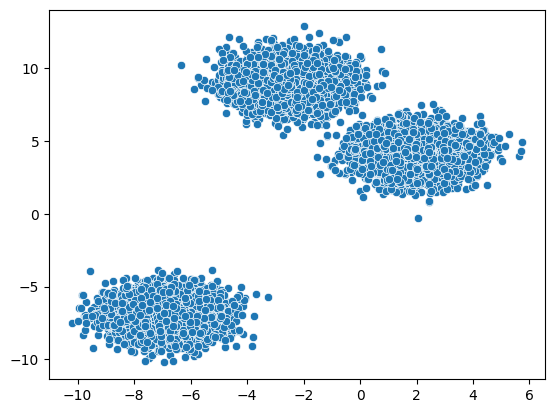

In [15]:
## Visualizing Plot 
sns.scatterplot(x=X[:,0],y=X[:,1])

In [16]:
## Applying K Means Clustering
from sklearn.cluster import KMeans
kmeans = KMeans(
     n_clusters=3,
     random_state=42
     
)
labels = kmeans.fit_predict(X)

- ***fit_predict( ):*** It is a convenience method that first fits the model on the dataset and then returns the predicted labels in a single step. It is commonly used in clustering algorithms like KMeans where we need cluster assignments immediately after training.

In [17]:
labels

array([1, 0, 1, ..., 2, 0, 0], shape=(9999,), dtype=int32)

<Axes: >

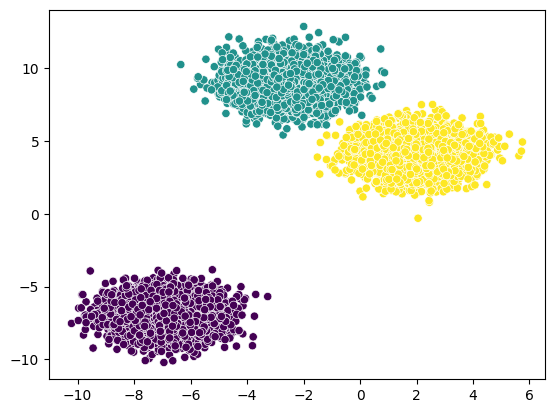

In [18]:
sns.scatterplot(x=X[:,0],y=X[:,1],c=labels)

- Choosing K Values
   - ***Elbow Method***
      - Elbow method is used to determine the optimal number of clusters in KMeans by plotting K vs WCSS (Within Cluster Sum of Squares) & K increases, WCSS decreases.
      - It measures cluster compactness
   - ***Silhouette Score***
      - Silhouette method evaluates how well each data point fits within its cluster compared to other clusters,lies between range (-1,1).
      - It measures cluster separation + cohesion.

In [ ]:
# Elbow Method
wcss = []
for k in range(1,21):
     kmeans = KMeans(n_clusters=k)
     kmeans.fit_predict(X)
     wcss.append(kmeans.inertia_)

<Axes: >

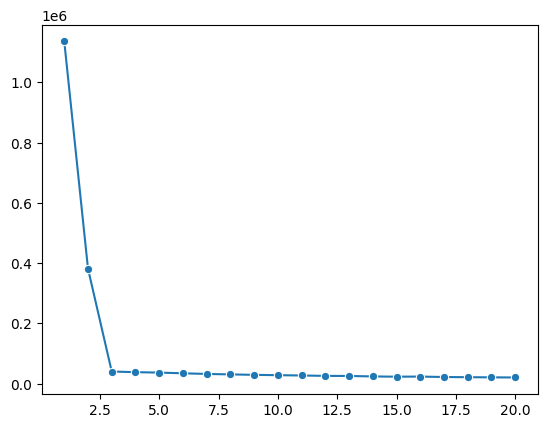

In [23]:
## Visualizing Graph
sns.lineplot(x=range(1,21),y=wcss,marker='o')

In [24]:
!pip install kneed

- ***Kneed Module*** (automatically find value of K for making clusters)

In [27]:
from kneed import KneeLocator
knee = KneeLocator(range(1,21),wcss,curve='convex',direction='decreasing')
print(f"Optimal Value of K:{knee.elbow}")

Optimal Value of K:3


In [29]:
# Silhouette Score 
from sklearn.metrics import silhouette_score
ss = []
for k in range(2,21):
     kmeans = KMeans(n_clusters=k)
     labels = kmeans.fit_predict(X)
     score = silhouette_score(X,labels)
     ss.append(score)

<Axes: >

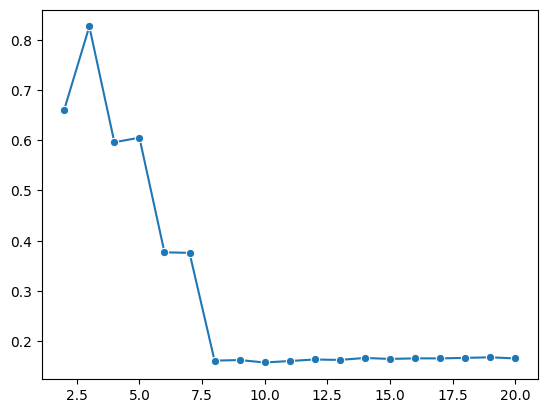

In [30]:
# Plot Graph
sns.lineplot(x=range(2,21),y=ss,marker='o')

***
- ***Hierarchical Clustering***
   - Hierarchical clustering builds a tree-like structure of clusters. It has two types: Agglomerative, which merges clusters bottom-up, and Divisive, which splits clusters top-down. The clustering process is visualized using a dendrogram, which helps determine the optimal number of clusters.

In [31]:
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Loading Dataset
iris = load_iris()
X = iris.data
y = iris.target

In [33]:
# Apply Scaling
scaler = StandardScaler()
x_scaled = scaler.fit_transform(X)

<Axes: >

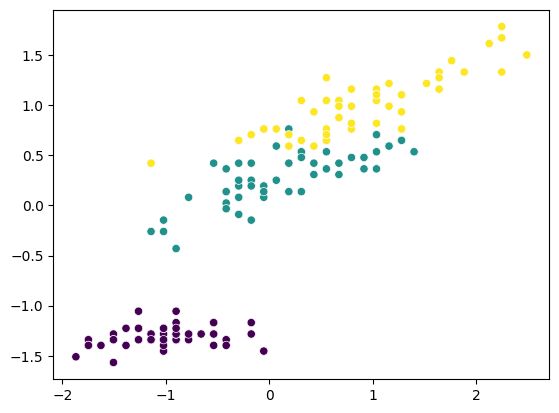

In [34]:
# Visualization
sns.scatterplot(x=x_scaled[:,0],y=x_scaled[:,2],c=y)

Text(0.5, 1.0, 'Dendogram for hierarchical Clustering')

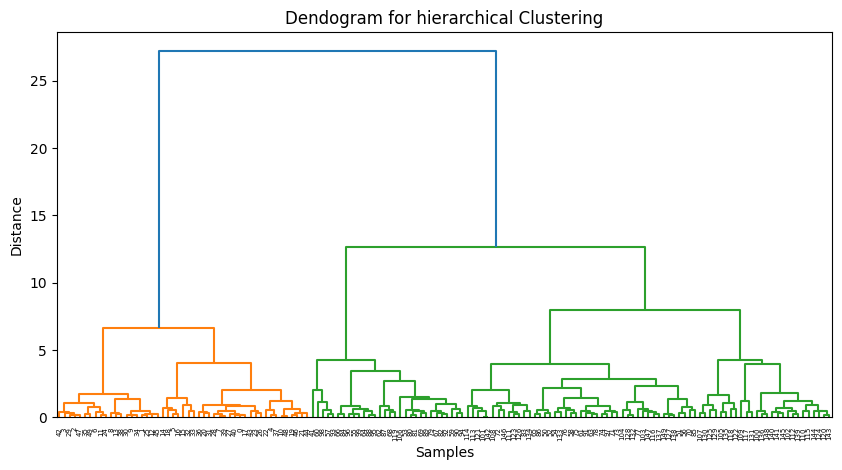

In [36]:
from scipy.cluster.hierarchy import linkage,dendrogram

# Linkage
z = linkage(x_scaled,method="ward")

# plot
plt.figure(figsize=(10,5))
dendrogram(z)
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.title("Dendogram for hierarchical Clustering")

In [40]:
# Agglomerative Clustering
from sklearn.cluster import AgglomerativeClustering
agg = AgglomerativeClustering(n_clusters=2,linkage='ward')
labels = agg.fit_predict(x_scaled)

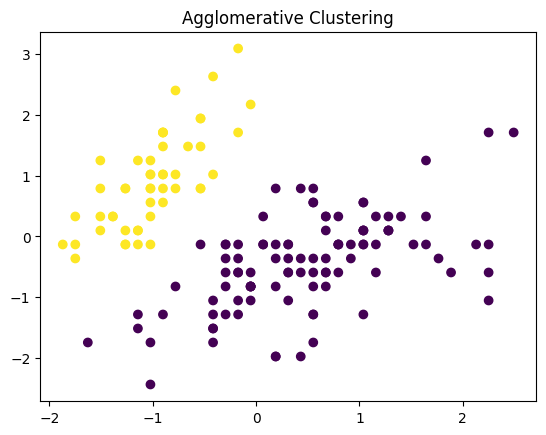

In [42]:
plt.scatter(x_scaled[:,0], x_scaled[:,1], c=labels)
plt.title("Agglomerative Clustering")
plt.show()

***
- ***DBSCAN***
   - DBSCAN is a density-based clustering algorithm that forms clusters based on data density. 
    - It uses two parameters: 
      - eps and min_samples. 
    - Unlike KMeans, it does not require specifying the number of clusters and can detect arbitrary-shaped clusters as well as outliers.


In [45]:
from sklearn.datasets import load_iris
import seaborn as sns
from sklearn.preprocessing import StandardScaler

iris = load_iris()

X = iris.data
y = iris.target

# Scaling
scaler = StandardScaler()
x_scaled = scaler.fit_transform(X)

<Axes: >

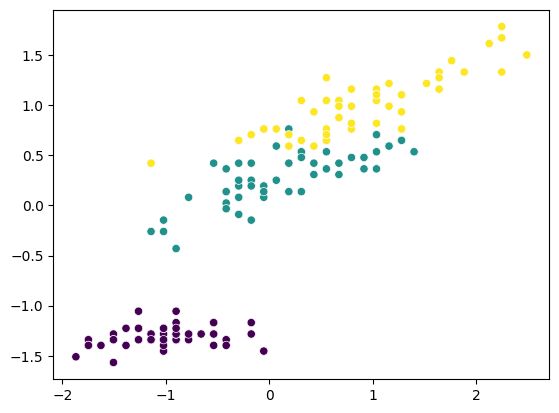

In [46]:
## Visualize
sns.scatterplot(x=x_scaled[:,0],y=x_scaled[:,2],c=y)

In [48]:
# DBSCAN

from sklearn.cluster import DBSCAN
dbscan = DBSCAN(
     eps=0.8,
     min_samples=6
)
labels = dbscan.fit_predict(x_scaled)

- Interview Specific Answer
   - eps defines the maximum neighborhood distance between two points, while min_samples defines the minimum number of points required within that neighborhood to form a dense region. Together, they control how clusters are formed and how noise is detected.

<Axes: >

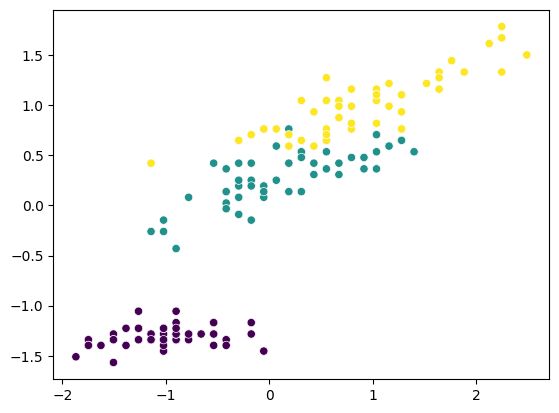

In [49]:
sns.scatterplot(x=x_scaled[:,0],y=x_scaled[:,2],c=y)

In [68]:
# Generating Non Linear Data
from sklearn.datasets import make_moons

X,y = make_moons(
     n_samples=499,
     noise=0.05,
     random_state=42
)

## Scaling
x_scaled = scaler.fit_transform(X)

<Axes: >

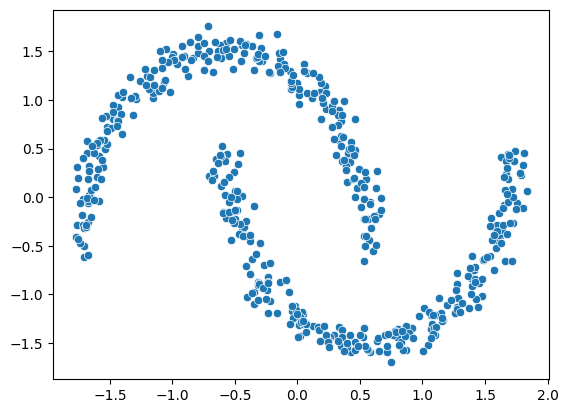

In [69]:
sns.scatterplot(x=x_scaled[:,0],y=x_scaled[:,1])

In [70]:
# Apply DBSCAN
dbscan = DBSCAN(
     eps=0.5,
     min_samples=5
)
labels = dbscan.fit_predict(x_scaled)

<Axes: >

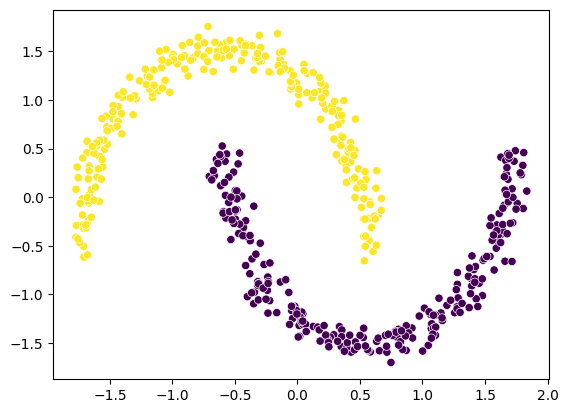

In [71]:
sns.scatterplot(x=x_scaled[:,0],y=x_scaled[:,1],c=labels)

- ***Anomaly Detection Using DBSCAN***

In [74]:
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons
import pandas as pd


X,y = make_moons(
     n_samples=499,
     noise=0.1,
     random_state=42
)

# Scaling
scaler = StandardScaler()
x_scaled = scaler.fit_transform(X)

<Axes: >

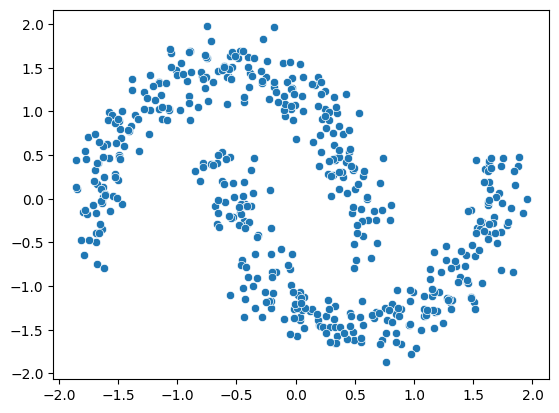

In [75]:
# Visualization
sns.scatterplot(x=x_scaled[:,0],y=x_scaled[:,1])

In [76]:
# DBSACN (preferred for non linear datasets)
dbscan = DBSCAN(
     eps= 0.18,
     min_samples=5
)
labels = dbscan.fit_predict(x_scaled)

<Axes: >

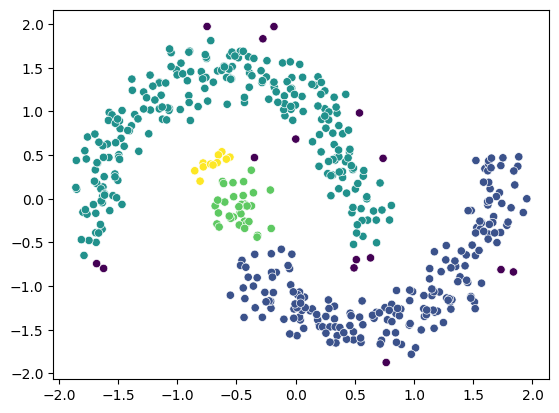

In [77]:
sns.scatterplot(x=x_scaled[:,0],y=x_scaled[:,1],c=labels)

***
- ***PCA***